# Dynamic Stomatal Conductance Model
## Reproducibility Repository — *Environmental Modelling & Software*

[![Python](https://img.shields.io/badge/Python-3.9%2B-blue.svg)](https://www.python.org/)
[![License: MIT](https://img.shields.io/badge/License-MIT-green.svg)](LICENSE)
[![DOI](https://img.shields.io/badge/DOI-pending-lightgrey.svg)]()
[![Journal](https://img.shields.io/badge/Journal-Env.%20Modelling%20%26%20Software-orange.svg)](https://www.sciencedirect.com/journal/environmental-modelling-and-software)

---

**Paper:**  
*Dynamic modeling of stomatal conductance for large-scale applications: integrating leaf temperature and environmental variables*

**Authors:**  
V. Niño-Celis¹, A. Rojas-Palma¹, S. Espinoza Meza², L.Y. Lara-Díaz¹, R. Guzman-Cruz³

> ¹ Doctorado en Modelamiento Matemático Aplicado, Universidad Católica del Maule, Talca, Chile  
> ² Departamento de Ciencias Forestales, Universidad Católica del Maule, Talca, Chile  
> ³ C.A. Bioingeniería Básica y Aplicada, Universidad Autónoma de Querétaro, México

**Funding:**  
ANID FONDECYT Regular No. 1240449 (PI: S. Espinoza Meza) · ANID Doctoral Fellowship 2024-21242105

---

## Purpose of this notebook

This notebook **fully reproduces** all calibration, sensitivity analysis, and model-comparison results reported in the paper. Running every cell from top to bottom generates:

- All time-series, DE-convergence, and parity figures (Figures 4, 5, 8, 9)
- Local sensitivity analysis rankings (Figure 6)
- Global Sobol sensitivity indices (Figure 7)
- Summary Excel workbook (Tables 2–4)

## Reproducibility notes

- Random seed is fixed at `SEED = 42` in **NumPy**, **random**, and the `seed` argument of `differential_evolution` — results are exactly reproducible.
- Python ≥ 3.9 is required. All dependencies are listed in `requirements.txt` in the repository root.
- The notebook runs on **Google Colab** (upload dialogs appear automatically) and **locally** (edit the file paths in Section 4).

## Repository structure

```
├── stomatal_conductance_model.ipynb   ← this notebook
├── requirements.txt                   ← pinned dependencies
├── README.md                          ← repository overview
├── data/
│   ├── Pinus_edulis.xlsx
│   ├── Juniperus_monosperma.xlsx
│   └── Quercus_ilex.xlsx
└── output_stomatal_model/             ← created at runtime
    ├── figures/   (.png + .tif, 600 dpi)
    └── stomatal_model_results.xlsx
```

## Input data schema

Each Excel file must contain the following columns:

| Column | Units | Description |
|---|---|---|
| `Species` | — | Species name (string) |
| `Treatment` | — | Water treatment (`Irrigation`, `Ambient`, or `—`) |
| `Grupo_Estacion` | — | Season group (`Verano-Primavera` / `Otoño-Invierno`) |
| `Time_30min` | HH:MM | Half-hour timestamp |
| `DateTime` | ISO 8601 | Full datetime |
| `Tleaf_mean` | °C | Mean leaf temperature |
| `Cond_mean` | mol m⁻² s⁻¹ | Mean stomatal conductance (gs) |
| `RelativeHumidity_irra` | % | Relative humidity |
| `AirTemperature_irra` | °C | Air temperature |
| `PPFDcal` or `PPFD` | µmol m⁻² s⁻¹ | Photosynthetic photon flux density |
| `Photo_mean` | µmol m⁻² s⁻¹ | Net photosynthesis *(Ball–Berry / Medlyn only)* |
| `CO2S_mean` | µmol mol⁻¹ | CO₂ concentration at leaf surface *(Ball–Berry / Medlyn only)* |

> **Data source:** Physiological data from Anderegg et al. (2018) via Figshare.  
> Meteorological data (GHI, DNI, RH, Ta) from NSRDB/NREL.


---
## 1. Environment Setup

Install and import all required libraries.  
If running on **Google Colab**, uncomment the `!pip install` line below.  
If running **locally**, install once with `pip install -r requirements.txt`.


In [1]:
# Uncomment the line below if running on Google Colab or a fresh environment:
# !pip install pandas numpy matplotlib openpyxl scikit-learn scipy SALib --quiet

import re
import time
import random
import shutil
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.optimize import differential_evolution
from scipy.stats import linregress

# SALib — Variance-based (Sobol) global sensitivity analysis
# Saltelli, A. et al. (2002). doi:10.1016/S0010-4655(02)00280-1
try:
    from SALib.sample import saltelli
    from SALib.analyze import sobol
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "SALib", "--quiet"])
    from SALib.sample import saltelli
    from SALib.analyze import sobol

from IPython.display import display

# ── Version check ─────────────────────────────────────────────────────────────
print("Libraries loaded successfully.")
print(f"  Python     : {__import__('sys').version.split()[0]}")
print(f"  NumPy      : {np.__version__}")
print(f"  Pandas     : {pd.__version__}")
print(f"  Matplotlib : {matplotlib.__version__}")


Libraries loaded successfully.
  Python     : 3.12.13
  NumPy      : 2.0.2
  Pandas     : 2.2.2
  Matplotlib : 3.10.0


---
## 2. Global Configuration

All adjustable constants are defined here in one place.  
**Do not modify constants inside other cells** — change them here to keep the notebook reproducible.

### Model parameter bounds (Table 1 of the paper)

| Parameter | Symbol | Lower bound | Upper bound | Unit | Physical meaning |
|---|---|---|---|---|---|
| `gmin` | g_min | 0.001 | 0.200 | mol m⁻² s⁻¹ | Minimum conductance (partially closed stomata) |
| `gmax` | g_max | 0.050 | 0.500 | mol m⁻² s⁻¹ | Maximum conductance (fully open stomata) |
| `alpha` | α | 1×10⁻⁴ | 1×10⁻² | mol µmol⁻¹ | Slope of irradiance–conductance relationship |
| `b1` | b₁ | 0.10 | 4.00 | kPa⁻¹ | VPD sensitivity coefficient |
| `ku` | k_u | 600 | 6 000 | s | Opening time constant |
| `kd` | k_d | 1 800 | 40 000 | s | Closing time constant |
| `T1` | T₁ | 5 | 15 | °C | Minimum temperature for stomatal opening |
| `T0` | T₀ | 15 | 30 | °C | Optimal temperature for maximum conductance |
| `Th` | T_h | 35 | 55 | °C | Maximum temperature before thermal closure |


In [2]:
# ── Reproducibility seed ─────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── PAR column names ──────────────────────────────────────────────────────────
# The notebook checks for PPFDcal first; falls back to PPFD if absent.
PAR_COL_PREF   = "PPFDcal"   # calibrated PPFD (preferred)
PAR_COL_BACKUP = "PPFD"      # raw PPFD (fallback)

# ── Medlyn model unit-conversion factor ──────────────────────────────────────
# 1.6 converts the ratio A/Ca from CO2-based to H2O-based conductance units.
FACTOR_MEDLYN = 1.6

# ── Parameter vector (order must match the bounds arrays below) ───────────────
PARAM_NAMES = ["gmin", "gmax", "alpha", "b1", "ku", "kd", "T1", "T0", "Th"]

# ── Differential Evolution search bounds (Table 1) ────────────────────────────
#               gmin    gmax    alpha    b1      ku      kd      T1    T0    Th
lower_DE = [0.001,  0.050,  1e-4,  0.10,   600.,  1800.,   5.,  15.,  35.]
upper_DE = [0.200,  0.500,  1e-2,  4.00,  6000., 40000.,  15.,  30.,  55.]
bounds_DE = list(zip(lower_DE, upper_DE))

# ── DE hyperparameters ────────────────────────────────────────────────────────
# Following SciPy differential_evolution defaults with best/1/bin strategy.
# Population size is set proportionally: 16 × n_parameters.
DE_MAXITER    = 150
DE_POPSIZE    = 16
DE_TOL        = 1e-6
DE_MUTATION   = (0.5, 1.0)   # dithered mutation [Storn & Price 1997]
DE_RECOMB     = 0.7          # crossover probability

# ── Reference model bounds ────────────────────────────────────────────────────
# Ball–Berry: (g0, m)
bounds_bb  = [(0.0, 0.5), (0.01, 50.0)]
# Medlyn:     (g0, g1)
bounds_med = [(0.0, 0.5), (0.01, 20.0)]

# ── Local Sensitivity Analysis (OAT) settings ─────────────────────────────────
LOCAL_PERTURB_FRAC = 0.30   # ± 30 % perturbation window around the optimum
LOCAL_N_GRID       = 30     # number of grid points per parameter sweep
LOCAL_DERIV_FRAC   = 0.05   # step size (± 5 %) for the centred finite difference

# ── Global Sensitivity Analysis (Sobol) settings ─────────────────────────────
# Total evaluations ≈ SOBOL_N × (2 × n_parameters + 2) = 256 × 20 = 5120
SOBOL_N                 = 256
SOBOL_CALC_SECOND_ORDER = False   # second-order indices are not reported in the paper

# Cases selected for Sobol analysis (Section 5.3 of the paper):
#   best fit  → Pinus edulis | Irrigation | Summer-Spring
#   worst fit → Juniperus monosperma | Autumn-Winter
# Stored as (Species, treatment-key, Grupo_Estacion) tuples.
SOBOL_CASES = [
    ("Pinus edulis",         "Irrigation", "Verano-Primavera"),
    ("Juniperus monosperma", "All",        "Otoño-Invierno"),
]

print("Configuration loaded.")
print(f"  Parameters : {PARAM_NAMES}")
print(f"  DE strategy: best/1/bin | maxiter={DE_MAXITER} | popsize={DE_POPSIZE}")
print(f"  Sobol N    : {SOBOL_N} (≈ {SOBOL_N*(2*len(PARAM_NAMES)+2)} evaluations per case)")


Configuration loaded.
  Parameters : ['gmin', 'gmax', 'alpha', 'b1', 'ku', 'kd', 'T1', 'T0', 'Th']
  DE strategy: best/1/bin | maxiter=150 | popsize=16
  Sobol N    : 256 (≈ 5120 evaluations per case)


---
## 3. Publication Figure Style

Global Matplotlib settings used for all figures in the paper:  
serif font (Times New Roman), 600 dpi save resolution, clean spines.


In [3]:
plt.rcParams.update({
    # Font
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset":  "stix",       # matches Times New Roman for math symbols
    # Sizes
    "font.size":         10,
    "axes.labelsize":    11,
    "axes.titlesize":    11,
    "legend.fontsize":   9,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    # Spines
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.linewidth":    0.8,
    # Lines
    "lines.linewidth":   1.6,
    # Resolution
    "figure.dpi":        150,          # screen rendering
    "savefig.dpi":       600,          # saved files (journal quality)
    "savefig.bbox":      "tight",
})

COLOR_DE  = "#1f77b4"   # blue  — DE-simulated gs
COLOR_OBS = "black"     # black — observed gs

print("Figure style applied (Times New Roman, 600 dpi).")


Figure style applied (Times New Roman, 600 dpi).


---
## 4. Data Loading and Validation

The analysis uses three separate Excel files — one per species.

**Google Colab:** Upload dialogs appear automatically when you run this cell.  
**Local execution:** Set the three `file_*` path variables in the `else` block below.

Each file is validated against the required column list before processing begins.


In [4]:
# ── Required columns (all three files must contain these) ────────────────────
REQUIRED_COLS = [
    "Species", "Treatment", "Grupo_Estacion", "Time_30min", "DateTime",
    "Tleaf_mean", "Cond_mean", "RelativeHumidity_irra", "AirTemperature_irra",
]


def select_ppfd(df: pd.DataFrame, label: str) -> str:
    """
    Select the PAR column available in *df*.

    Checks for PPFDcal first (calibrated irradiance), then falls back to PPFD.
    Raises ValueError if neither column is found.
    """
    if PAR_COL_PREF in df.columns:
        print(f"  [{label}] PAR column → '{PAR_COL_PREF}'")
        return PAR_COL_PREF
    if PAR_COL_BACKUP in df.columns:
        print(f"  [{label}] PAR column → '{PAR_COL_BACKUP}' (fallback)")
        return PAR_COL_BACKUP
    raise ValueError(
        f"[{label}] Neither '{PAR_COL_PREF}' nor '{PAR_COL_BACKUP}' found. "
        "Add one of these columns to the file.")


def read_validate(filepath: str, label: str) -> tuple[pd.DataFrame, str]:
    """
    Load an Excel file, validate required columns, and return (df, par_col).

    Parameters
    ----------
    filepath : path to the .xlsx file
    label    : human-readable species label used in log messages

    Returns
    -------
    df      : validated DataFrame with cleaned string columns
    par_col : name of the PAR column to use ('PPFDcal' or 'PPFD')
    """
    df = pd.read_excel(filepath)
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"[{label}] Missing required columns: {missing}")
    # Normalise string columns
    df["Species"]        = df["Species"].astype(str).str.strip()
    df["Treatment"]      = df["Treatment"].astype(str).str.strip()
    df["Grupo_Estacion"] = df["Grupo_Estacion"].astype(str).str.strip()
    df["DateTime"]       = pd.to_datetime(df["DateTime"], errors="coerce")
    par = select_ppfd(df, label)
    return df, par


# ── Detect execution environment ──────────────────────────────────────────────
try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── Load files ────────────────────────────────────────────────────────────────
if IN_COLAB:
    # Google Colab — interactive upload dialogs
    print("Upload 1/3: PINUS EDULIS file")
    file_pinus = list(colab_files.upload().keys())[0]

    print("\nUpload 2/3: JUNIPERUS MONOSPERMA file")
    file_jun = list(colab_files.upload().keys())[0]

    print("\nUpload 3/3: QUERCUS file")
    file_quercus = list(colab_files.upload().keys())[0]

else:
    # ── LOCAL PATHS — edit these three lines ─────────────────────────────────
    file_pinus   = "data/Pinus_edulis.xlsx"
    file_jun     = "data/Juniperus_monosperma.xlsx"
    file_quercus = "data/Quercus_ilex.xlsx"

print("\nLoading and validating files...")
df_pinus,   par_pinus   = read_validate(file_pinus,   "Pinus edulis")
df_jun,     par_jun     = read_validate(file_jun,     "Juniperus monosperma")
df_quercus, par_quercus = read_validate(file_quercus, "Quercus ilex")

print(f"\nFiles loaded successfully:")
print(f"  Pinus edulis         : {len(df_pinus):>5} rows")
print(f"  Juniperus monosperma : {len(df_jun):>5} rows")
print(f"  Quercus ilex         : {len(df_quercus):>5} rows")


Upload 1/3: PINUS EDULIS file


Saving PinusAgrupacionEstacion.xlsx to PinusAgrupacionEstacion.xlsx

Upload 2/3: JUNIPERUS MONOSPERMA file


Saving PinusAgrupacionEstacion.xlsx to PinusAgrupacionEstacion (1).xlsx

Upload 3/3: QUERCUS file


Saving QuercusAgrupacionEstacion.xlsx to QuercusAgrupacionEstacion.xlsx

Loading and validating files...
  [Pinus edulis] PAR column → 'PPFDcal'
  [Juniperus monosperma] PAR column → 'PPFDcal'
  [Quercus ilex] PAR column → 'PPFDcal'

Files loaded successfully:
  Pinus edulis         :   704 rows
  Juniperus monosperma :   704 rows
  Quercus ilex         :    83 rows


---
## 5. Analysis Subsets

The dataset is divided into five subsets, one for each row of **Table 2** in the paper:

| # | Species | Treatment | Season |
|---|---|---|---|
| 1 | *Pinus edulis* | Ambient | Summer–Spring |
| 2 | *Pinus edulis* | Irrigation | Summer–Spring |
| 3 | *Juniperus monosperma* | — | Summer–Spring |
| 4 | *Juniperus monosperma* | — | Autumn–Winter |
| 5 | *Quercus* sp. | — | Summer–Spring |

Each subset is stored as a dictionary with keys `data`, `par_col`, `title`, `fig_base`, `Species`, `Treatment`, and `Grupo_Estacion`.


In [5]:
# ── Helper functions for label normalisation ──────────────────────────────────

def safe_name(text: str) -> str:
    """Convert a string to a filesystem-safe identifier (no spaces or special chars)."""
    text = str(text).strip().replace(" ", "_")
    return re.sub(r"[^A-Za-z0-9_\-]", "", text)


def translate_season(season: str) -> str:
    """Translate Spanish season labels to English for output tables and filenames."""
    mapping = {
        "Verano-Primavera": "Summer-Spring",
        "Otoño-Invierno":   "Autumn-Winter",
    }
    return mapping.get(season, season)


def translate_treatment(species: str, treatment: str) -> str:
    """
    Normalise treatment labels to English.

    - Pinus edulis non-irrigation → 'Ambient'
    - All other null/placeholder values → 'All' (used for species with no treatment split)
    """
    if species == "Pinus edulis" and treatment not in ("Irrigation",):
        return "Ambient"
    if treatment in ("ALL", "All", "-", "--", "", "nan", "None", "NO_APLICA"):
        return "All"
    return treatment


# ── Build subset list ─────────────────────────────────────────────────────────
subsets = []

# 1. Pinus edulis | Ambient | Summer-Spring
mask = (df_pinus["Species"].str.contains("Pinus edulis", case=False, na=False)
        & (df_pinus["Treatment"] == "Ambient")
        & (df_pinus["Grupo_Estacion"] == "Verano-Primavera"))
if mask.sum() > 0:
    subsets.append(dict(data=df_pinus[mask].copy(), par_col=par_pinus,
        title="Pinus edulis | Ambient | Summer-Spring",
        fig_base="Pinus_edulis__Ambient__Summer_Spring",
        Species="Pinus edulis", Treatment="Ambient",
        Grupo_Estacion="Verano-Primavera"))

# 2. Pinus edulis | Irrigation | Summer-Spring
mask = (df_pinus["Species"].str.contains("Pinus edulis", case=False, na=False)
        & (df_pinus["Treatment"] == "Irrigation")
        & (df_pinus["Grupo_Estacion"] == "Verano-Primavera"))
if mask.sum() > 0:
    subsets.append(dict(data=df_pinus[mask].copy(), par_col=par_pinus,
        title="Pinus edulis | Irrigation | Summer-Spring",
        fig_base="Pinus_edulis__Irrigation__Summer_Spring",
        Species="Pinus edulis", Treatment="Irrigation",
        Grupo_Estacion="Verano-Primavera"))

# 3. Juniperus monosperma | Summer-Spring
mask = (df_jun["Species"].str.contains("Juniperus monosperma", case=False, na=False)
        & (df_jun["Grupo_Estacion"] == "Verano-Primavera"))
if mask.sum() > 0:
    subsets.append(dict(data=df_jun[mask].copy(), par_col=par_jun,
        title="Juniperus monosperma | Summer-Spring",
        fig_base="Juniperus_monosperma__Summer_Spring",
        Species="Juniperus monosperma", Treatment="All",
        Grupo_Estacion="Verano-Primavera"))

# 4. Juniperus monosperma | Autumn-Winter
mask = (df_jun["Species"].str.contains("Juniperus monosperma", case=False, na=False)
        & (df_jun["Grupo_Estacion"] == "Otoño-Invierno"))
if mask.sum() > 0:
    subsets.append(dict(data=df_jun[mask].copy(), par_col=par_jun,
        title="Juniperus monosperma | Autumn-Winter",
        fig_base="Juniperus_monosperma__Autumn_Winter",
        Species="Juniperus monosperma", Treatment="All",
        Grupo_Estacion="Otoño-Invierno"))

# 5. Quercus sp. | Summer-Spring
mask = (df_quercus["Species"].str.contains("Quercus", case=False, na=False)
        & (df_quercus["Grupo_Estacion"] == "Verano-Primavera"))
if mask.sum() > 0:
    subsets.append(dict(data=df_quercus[mask].copy(), par_col=par_quercus,
        title="Quercus sp. | Summer-Spring",
        fig_base="Quercus__Summer_Spring",
        Species="Quercus", Treatment="All",
        Grupo_Estacion="Verano-Primavera"))

if not subsets:
    raise ValueError(
        "No valid subsets found. Check that species names and season labels "
        "in the Excel files match the expected values above.")

print("Analysis subsets built:")
for i, s in enumerate(subsets, 1):
    print(f"  {i}. {s['title']:<50}  n = {len(s['data'])}")


Analysis subsets built:
  1. Pinus edulis | Ambient | Summer-Spring              n = 78
  2. Pinus edulis | Irrigation | Summer-Spring           n = 223
  3. Juniperus monosperma | Summer-Spring                n = 313
  4. Juniperus monosperma | Autumn-Winter                n = 46
  5. Quercus sp. | Summer-Spring                         n = 65


---
## 6. Utility Functions

### 6.1 Time parsing and 30-minute aggregation

Raw observations are aggregated to 30-minute means before modelling.  
The `aggregate_halfhour` function groups by `Time_30min` and computes means of gs, PAR, Tleaf, Tair, and RH.  
`parse_time_to_hours` handles the variety of time formats found in the input files (datetime objects, "HH:MM" strings, numeric hours).


In [6]:
def parse_time_to_hours(v) -> float:
    """
    Convert a time value to decimal hours.

    Accepts: Python datetime/time objects, 'HH:MM:SS' strings, numeric hours.
    Returns NaN for missing or unparsable values.
    """
    if pd.isna(v):
        return np.nan
    if hasattr(v, "hour"):
        return float(v.hour) + float(v.minute) / 60 + float(getattr(v, "second", 0)) / 3600
    s = str(v).strip()
    if s.lower() in {"nan", "nat", "none", ""}:
        return np.nan
    if " " in s:
        s = s.split(" ")[-1]   # strip date prefix if present
    parts = s.split(":")
    try:
        hh = int(float(parts[0]))
        mm = int(float(parts[1])) if len(parts) > 1 else 0
        ss = float(parts[2])      if len(parts) > 2 else 0.0
        return hh + mm / 60 + ss / 3600
    except Exception:
        return np.nan


def to_hours(arr) -> np.ndarray:
    """Convert an array of mixed time values to decimal hours, interpolating gaps."""
    v = pd.Series(arr).apply(parse_time_to_hours).to_numpy(dtype=float)
    if np.isnan(v).all():
        # Fall back to uniform 30-min spacing if all values are unparsable
        v = np.arange(len(v), dtype=float) * 0.5
    else:
        v = pd.Series(v).interpolate(limit_direction="both").to_numpy()
    return v


def fmt_label(v) -> str:
    """Format a time value as an 'HH:MM' string for axis tick labels."""
    h = parse_time_to_hours(v)
    if np.isnan(h):
        s = str(v).strip()
        return "" if s.lower() in {"nan", "nat", "none", ""} else s
    hh = int(h)
    mm = int(round((h - hh) * 60))
    if mm == 60:
        hh += 1; mm = 0
    return f"{hh % 24:02d}:{mm:02d}"


def time_labels(arr) -> np.ndarray:
    """Apply fmt_label to an array and return a string array of HH:MM labels."""
    return np.array([fmt_label(v) for v in arr], dtype=object)


def publication_xticks(t_num, t_lbl, every: int = 4, min_gap_hours: float = 0.75):
    """
    Select a sparse, non-overlapping subset of x-tick positions for publication figures.

    Parameters
    ----------
    t_num        : numeric decimal-hour positions of all data points
    t_lbl        : corresponding HH:MM label strings
    every        : keep every N-th tick
    min_gap_hours: suppress the last tick if it is closer than this to the previous one
                   (prevents labels like '17:00' and '17:30' from overlapping)

    Returns
    -------
    (tick_positions, tick_labels) — arrays ready for ax.set_xticks / set_xticklabels
    """
    idx  = list(np.arange(0, len(t_num), every))
    last = len(t_num) - 1
    if not idx:
        idx = [0, last]
    elif idx[-1] != last:
        if (t_num[last] - t_num[idx[-1]]) >= min_gap_hours:
            idx.append(last)
    idx = np.array(idx)
    return t_num[idx], t_lbl[idx]


def aggregate_halfhour(df: pd.DataFrame, par_col: str) -> pd.DataFrame | None:
    """
    Aggregate raw gas-exchange observations to 30-minute means.

    Drops rows with any NaN in the required columns, groups by Time_30min,
    and computes mean ± std for gs, PAR, Tleaf, Tair, and RH.

    Returns None if fewer than 6 time steps remain after aggregation
    (insufficient for ODE integration and meaningful calibration).
    """
    keep = ["Species", "Treatment", "Grupo_Estacion", "Time_30min", "DateTime",
            "RelativeHumidity_irra", "Tleaf_mean", "Cond_mean",
            par_col, "AirTemperature_irra"]
    sub = df[keep].dropna().copy()
    if len(sub) < 6:
        return None
    st = (sub.groupby("Time_30min")
              .agg(n_obs    =("Cond_mean",  "count"),
                   gs_mean  =("Cond_mean",  "mean"),
                   gs_std   =("Cond_mean",  "std"),
                   PAR_mean =(par_col,      "mean"),
                   Tl_mean  =("Tleaf_mean", "mean"),
                   Ta_mean  =("AirTemperature_irra", "mean"),
                   RH_mean  =("RelativeHumidity_irra","mean"))
              .reset_index()
              .sort_values("Time_30min"))
    return st if len(st) >= 6 else None


def extract_arrays(st: pd.DataFrame) -> dict:
    """
    Convert an aggregated 30-min DataFrame to NumPy arrays for model integration.

    Returns
    -------
    dict with keys:
        t_raw  — original Time_30min values
        t_lbl  — HH:MM string labels
        t_num  — decimal hours (for plotting)
        PAR    — photosynthetic photon flux density (µmol m⁻² s⁻¹)
        Tleaf  — leaf temperature (°C)
        Tair   — air temperature (°C)
        RH     — relative humidity (%)
        gs_obs — observed stomatal conductance (mol m⁻² s⁻¹)
        n_obs  — number of raw observations per 30-min bin
        dt     — time step array (seconds) — constant 1800 s between consecutive points
    """
    t_raw = st["Time_30min"].to_numpy()
    t_lbl = time_labels(t_raw)
    t_num = to_hours(t_raw)
    return {
        "t_raw": t_raw, "t_lbl": t_lbl, "t_num": t_num,
        "PAR":   st["PAR_mean"].to_numpy(float),
        "Tleaf": st["Tl_mean"].to_numpy(float),
        "Tair":  st["Ta_mean"].to_numpy(float),
        "RH":    st["RH_mean"].to_numpy(float),
        "gs_obs":st["gs_mean"].to_numpy(float),
        "n_obs": st["n_obs"].to_numpy(int),
        "dt":    np.full(len(t_raw) - 1, 1800.0),  # 30 min in seconds
    }

print("Time-parsing and aggregation utilities defined.")


Time-parsing and aggregation utilities defined.


### 6.2 Physiological sub-functions — Equations (1)–(8)

The equilibrium conductance is a multiplicative product of three dimensionless response functions  
(Jarvis 1976 scheme, Eq. 1):

$$G(Q, T_l, VPD_l) = G_{s,1}(Q) \cdot G_{s,2}(T_l) \cdot G_{s,3}(VPD_l)$$

Each sub-function is implemented below with the equation number from the paper as a reference.


In [7]:
# ── Vapour pressure — Eqs. (5)–(7) ───────────────────────────────────────────

def esat(T: np.ndarray) -> np.ndarray:
    """
    Saturation vapour pressure using the Tetens equation — Eq. (6).

    e_s(T) = 0.6108 · exp(17.27 T / (T + 237.3))   [kPa]

    Temperature is clipped to [−10, 60] °C to prevent numerical overflow.
    """
    T = np.clip(T, -10, 60)
    return 0.6108 * np.exp(17.27 * T / (T + 237.3))


def calc_VPD(Tleaf, Tair, RH) -> np.ndarray:
    """
    Leaf-to-air vapour pressure deficit — Eqs. (5)–(7).

    VPD_l = e_s(T_l) − e_a,  where  e_a = (RH/100) · e_s(T_a)   [kPa]

    Using T_leaf (not T_air) for the saturation term gives the actual
    evaporative gradient driving transpiration (rather than the atmospheric VPD).
    Clipped to [0, 10] kPa.
    """
    return np.clip(esat(Tleaf) - (RH / 100.0) * esat(Tair), 0.0, 10.0)


def calc_hs(Tleaf, Tair, RH) -> np.ndarray:
    """
    Fractional leaf-surface relative humidity — used only by Ball–Berry.

    h_s = 1 − VPD_l / e_s(T_l)   [dimensionless, 0–1]
    """
    vpd = calc_VPD(Tleaf, Tair, RH)
    return np.clip(1.0 - vpd / np.maximum(esat(Tleaf), 1e-6), 0.0, 1.0)


# ── Light response — Eq. (2) ──────────────────────────────────────────────────

def Gs_I(I, gmin, gmax, alpha) -> np.ndarray:
    """
    Irradiance response component G_s,1(Q) — Eq. (2).

    Non-rectangular hyperbola saturating between g_min and g_max:

        G_s,1 = g_min + α·Q·(g_max − g_min) / √[(g_max − g_min)² + (α·Q)²]

    - At Q → 0 :  G_s,1 → g_min  (dark conductance)
    - At Q → ∞ :  G_s,1 → g_max  (light-saturated conductance)
    - α controls the initial slope of the light-response curve.
    """
    dg = gmax - gmin
    return gmin + alpha * I * dg / (np.sqrt(dg**2 + (alpha * I)**2) + 1e-12)


# ── Temperature response — Eqs. (3)–(4) ──────────────────────────────────────

def Gs_Tleaf(Tleaf, T1, T0, Th) -> np.ndarray:
    """
    Leaf-temperature response component G_s,2(T_l) — Eqs. (3)–(4).

    Asymmetric unimodal function:

        G_s,2 = b2 · (T_l − T1) · (Th − T_l)^b3   for T1 < T_l < Th
              = 0                                     otherwise

    where b3 = (Th − T0)/(T0 − T1)  and  b2 = 1/[(T0−T1)·(Th−T0)^b3].

    The normalisation ensures G_s,2(T0) = 1 exactly.
    Returns a dimensionless array in [0, 1].

    Numerical safeguards:
        - Requires T1 < T0 < Th and min 0.5 °C margin around T0.
        - b3 is capped at 20 to prevent overflow in np.power.
        - All non-finite values are zeroed before clipping.
    """
    Tleaf = np.asarray(Tleaf, dtype=float)
    if not (T1 < T0 < Th) or (T0 - T1) < 0.5 or (Th - T0) < 0.5:
        return np.zeros_like(Tleaf)
    b3 = (Th - T0) / (T0 - T1)
    if b3 <= 0 or b3 > 20:
        return np.zeros_like(Tleaf)
    den = (T0 - T1) * (Th - T0) ** b3
    if not np.isfinite(den) or den <= 0:
        return np.zeros_like(Tleaf)
    b2  = 1.0 / den
    val = np.zeros_like(Tleaf)
    mask = (Tleaf > T1) & (Tleaf < Th)
    val[mask] = b2 * (Tleaf[mask] - T1) * np.power(Th - Tleaf[mask], b3)
    return np.clip(np.nan_to_num(val, nan=0.0, posinf=0.0, neginf=0.0), 0.0, 1.0)


# ── VPD response — Eq. (8) ───────────────────────────────────────────────────

def Gs_VPD(vpd, b1) -> np.ndarray:
    """
    Vapour pressure deficit response component G_s,3(VPD_l) — Eq. (8).

    Decreasing hyperbolic function following Leuning (1995):

        G_s,3 = 1 / (1 + b1 · VPD_l)   [dimensionless, in (0, 1]]

    - As VPD_l → 0: G_s,3 → 1 (no stomatal closure from VPD)
    - Increases in b1 amplify stomatal sensitivity to atmospheric water demand.
    """
    return 1.0 / (1.0 + b1 * vpd)


# ── Combined equilibrium target — Eq. (1) ────────────────────────────────────

def G_target(I, Tleaf, Tair, RH, gmin, gmax, alpha, b1, T1, T0, Th) -> np.ndarray:
    """
    Equilibrium stomatal conductance G(Q, T_l, VPD_l) — Eq. (1).

    Multiplicative Jarvis scheme:
        G = G_s,1(Q)  ×  G_s,2(T_l)  ×  G_s,3(VPD_l)

    This is the target (steady-state) value toward which the ODE (Eq. 9) drives gs(t).
    """
    return (Gs_I(I, gmin, gmax, alpha)
            * Gs_Tleaf(Tleaf, T1, T0, Th)
            * Gs_VPD(calc_VPD(Tleaf, Tair, RH), b1))

print("Physiological sub-functions defined (Eqs. 1–8).")


Physiological sub-functions defined (Eqs. 1–8).


---
## 7. Model Definitions

### 7.1 Dynamic stomatal conductance model — Eq. (9)

The dynamic model combines the equilibrium target G(Q, T_l, VPD_l) with an  
**asymmetric ordinary differential equation** that distinguishes between stomatal  
opening (time constant k_u) and closing (time constant k_d):

$$\frac{dg_s(t)}{dt} = \begin{cases} \dfrac{G - g_s(t)}{k_u} & \text{if } G \geq g_s(t) \\[6pt] \dfrac{G - g_s(t)}{k_d} & \text{if } G < g_s(t) \end{cases}$$

The ODE is integrated with a first-order Euler scheme at 30-minute time steps.


In [8]:
def simulate_gs(theta, PAR, Tleaf, Tair, RH, gs_obs, dt) -> np.ndarray:
    """
    Simulate stomatal conductance using the asymmetric ODE — Eq. (9).

    Integration uses a first-order forward Euler scheme with Δt = 1800 s (30 min).
    gs is initialised to the first observed value.

    Parameters
    ----------
    theta   : array-like of length 9
              [gmin, gmax, alpha, b1, ku, kd, T1, T0, Th]
    PAR     : PPFD time series (µmol m⁻² s⁻¹), length n
    Tleaf   : leaf temperature time series (°C), length n
    Tair    : air temperature time series (°C), length n
    RH      : relative humidity time series (%), length n
    gs_obs  : observed gs (mol m⁻² s⁻¹) — used only to set gs[0]
    dt      : array of time step durations in seconds, length n−1

    Returns
    -------
    gs : simulated conductance time series (mol m⁻² s⁻¹), length n
         Returns NaN array if T1 ≥ T0 or T0 ≥ Th (invalid thermal parameters).
    """
    gmin, gmax, alpha, b1, ku, kd, T1, T0, Th = theta
    if not (T1 < T0 < Th):
        return np.full_like(gs_obs, np.nan)
    gs    = np.zeros(len(PAR), dtype=float)
    gs[0] = max(gs_obs[0], 0.0)
    for t in range(1, len(PAR)):
        Gt      = G_target(PAR[t], Tleaf[t], Tair[t], RH[t],
                           gmin, gmax, alpha, b1, T1, T0, Th)
        tau     = ku if Gt >= gs[t - 1] else kd   # asymmetric time constant
        gs[t]   = gs[t - 1] + (Gt - gs[t - 1]) / max(tau, 1.0) * dt[t - 1]
    return np.clip(np.nan_to_num(gs, nan=0.0, posinf=0.0, neginf=0.0), 0.0, 2.0)


def rmse_objective(theta, data: dict) -> float:
    """
    Objective function for Differential Evolution — Eq. (12).

    Returns the RMSE between observed and simulated gs.
    Returns 1e9 (penalty) if the simulation produces NaN values.
    """
    gs_sim = simulate_gs(theta, data["PAR"], data["Tleaf"], data["Tair"],
                         data["RH"], data["gs_obs"], data["dt"])
    if np.any(np.isnan(gs_sim)):
        return 1e9
    return float(np.sqrt(np.mean((data["gs_obs"] - gs_sim) ** 2)))

print("Dynamic model (Eq. 9) defined.")


Dynamic model (Eq. 9) defined.


### 7.2 Reference models — Ball–Berry (Eq. 10) and Medlyn (Eq. 11)

Two widely used steady-state models are fitted to the same observed data  
for functional comparison (Section 5.5 of the paper).

> **Important:** These models require `Photo_mean` (net photosynthesis, A)  
> and `CO2S_mean` (CO₂ concentration at the leaf surface, C_s).  
> The dynamic model does **not** require these variables.


In [9]:
def gs_ball_berry(A, hs, Cs, g0, m) -> np.ndarray:
    """
    Ball–Berry empirical model — Eq. (10).

        g_s = g0 + m · (A · h_s) / C_s

    Parameters
    ----------
    A   : net CO₂ assimilation rate (µmol m⁻² s⁻¹)
    hs  : fractional relative humidity at the leaf surface (dimensionless)
    Cs  : CO₂ concentration at the leaf surface (µmol mol⁻¹)
    g0  : residual (minimum) conductance (mol m⁻² s⁻¹)
    m   : empirical slope parameter (dimensionless)

    Reference: Ball et al. (1987).
    """
    return np.clip(g0 + m * (A * hs) / np.maximum(Cs, 1e-6), 0.0, 2.0)


def gs_medlyn(A, D, Ca, g0, g1, factor: float = FACTOR_MEDLYN) -> np.ndarray:
    """
    Medlyn et al. (2011) optimal stomatal model — Eq. (11).

        g_s = g0 + 1.6 · (1 + g1/√D) · (A / C_a)

    Derived from stomatal optimality theory (carbon gain vs. water cost trade-off).
    The 1.6 factor converts CO₂ conductance to H₂O conductance.

    Parameters
    ----------
    A   : net CO₂ assimilation rate (µmol m⁻² s⁻¹)
    D   : vapour pressure deficit (kPa)
    Ca  : CO₂ concentration in the air (µmol mol⁻¹)
    g0  : residual conductance (mol m⁻² s⁻¹)
    g1  : sensitivity parameter to VPD (kPa^0.5)
    factor : unit-conversion factor (default 1.6)

    Reference: Medlyn et al. (2011). doi:10.1111/j.1365-2486.2010.02375.x
    """
    return np.clip(
        g0 + factor * (1.0 + g1 / np.sqrt(np.maximum(D, 1e-6)))
           * A / np.maximum(Ca, 1e-6),
        0.0, 2.0)

print("Reference models defined (Ball-Berry Eq. 10; Medlyn Eq. 11).")


Reference models defined (Ball-Berry Eq. 10; Medlyn Eq. 11).


---
## 8. Performance Metrics

Four metrics are computed between observed and simulated gs:

| Metric | Symbol | Description |
|---|---|---|
| RMSE | — | Root mean square error — minimised by DE (Eq. 12) |
| R² | R² | Coefficient of determination — variance explained |
| MAE | — | Mean absolute error (same units as gs) |
| Slope | — | Slope of the simulated-vs-observed linear regression (parity bias) |

Slopes close to 1.0 indicate low systematic bias; slopes < 1.0 indicate underestimation of peak gs.


In [10]:
def compute_metrics(yo, ys) -> dict:
    """
    Compute RMSE, R², MAE, and parity slope between observed and simulated arrays.

    Finite-value mask is applied before all calculations.
    Returns NaN for all metrics if fewer than 2 valid pairs exist.

    Returns dict with keys: RMSE, R2, MAE, Slope
    """
    yo, ys = np.asarray(yo, float), np.asarray(ys, float)
    m = np.isfinite(yo) & np.isfinite(ys)
    yo, ys = yo[m], ys[m]
    if len(yo) < 2:
        return dict(RMSE=np.nan, R2=np.nan, MAE=np.nan, Slope=np.nan)
    try:
        slope = float(np.polyfit(yo, ys, 1)[0])
    except Exception:
        slope = np.nan
    return dict(
        RMSE =float(np.sqrt(np.mean((yo - ys) ** 2))),
        R2   =float(r2_score(yo, ys)),
        MAE  =float(mean_absolute_error(yo, ys)),
        Slope=slope,
    )


def compute_metrics_full(obs, sim) -> dict:
    """
    Extended metrics including mean bias, full regression statistics, and p-value.
    Used in the three-model comparison table (Section 5.5).

    Returns dict with keys:
        RMSE, MAE, Bias, R2, Slope, Intercept, R, p_value, StdErr
    """
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs, sim = obs[mask], sim[mask]
    if len(obs) < 2:
        return {k: np.nan for k in
                ["RMSE", "MAE", "Bias", "R2", "Slope", "Intercept", "R", "p_value", "StdErr"]}
    reg = linregress(obs, sim)
    return dict(
        RMSE     =float(np.sqrt(np.mean((obs - sim) ** 2))),
        MAE      =float(mean_absolute_error(obs, sim)),
        Bias     =float(np.mean(sim - obs)),   # positive = model overestimates
        R2       =float(r2_score(obs, sim)),
        Slope    =float(reg.slope),
        Intercept=float(reg.intercept),
        R        =float(reg.rvalue),
        p_value  =float(reg.pvalue),
        StdErr   =float(reg.stderr),
    )

print("Performance metric functions defined.")


Performance metric functions defined.


---
## 9. Local Sensitivity Analysis (OAT)

Normalised one-at-a-time (OAT) sensitivity index (Section 4.3):

$$S^*_i = \frac{\theta_i}{\text{RMSE}} \cdot \frac{\partial \text{RMSE}}{\partial \theta_i}$$

approximated by a **centred finite difference** around the DE optimum:

$$S^*_i \approx \frac{\theta_i}{\text{RMSE}} \cdot \frac{\text{RMSE}(\theta_i^+) - \text{RMSE}(\theta_i^-)}{\theta_i^+ - \theta_i^-}$$

where θ_i± = θ_i · (1 ± 5%).  
A sweep of ±30% around the optimum is also computed to visualise the RMSE–parameter response curve.


In [11]:
def clamp(x, lo, hi):
    """Clamp x to the interval [lo, hi]."""
    return max(lo, min(hi, x))


def evaluate_theta(theta, data: dict) -> tuple:
    """
    Simulate gs and compute metrics for a given parameter vector.

    Returns (gs_sim, metrics_dict).
    """
    gs_sim = simulate_gs(theta, data["PAR"], data["Tleaf"], data["Tair"],
                         data["RH"], data["gs_obs"], data["dt"])
    return gs_sim, compute_metrics(data["gs_obs"], gs_sim)


def make_param_grid(theta0, i: int,
                    frac: float = LOCAL_PERTURB_FRAC,
                    n: int = LOCAL_N_GRID) -> np.ndarray:
    """
    Build a uniform grid of n values around theta0[i] within ±frac%.

    The grid is clamped to the DE bounds to avoid evaluating outside
    the physiologically plausible range.
    """
    base = theta0[i]
    lo   = max(lower_DE[i], base * (1.0 - frac))
    hi   = min(upper_DE[i], base * (1.0 + frac))
    if not (np.isfinite(lo) and np.isfinite(hi)) or lo == hi:
        lo, hi = lower_DE[i], upper_DE[i]
    return np.linspace(lo, hi, n)


def normalized_local_sensitivity(theta0, i: int, data: dict,
                                  frac: float = LOCAL_DERIV_FRAC) -> float:
    """
    Compute the normalised local sensitivity index S*_i via centred differences.

    Returns NaN if the base RMSE is zero or non-finite (degenerate case).
    """
    p0 = theta0[i]
    if not np.isfinite(p0) or abs(p0) < 1e-12:
        return np.nan
    pm = clamp(p0 * (1 - frac), lower_DE[i], upper_DE[i])
    pp = clamp(p0 * (1 + frac), lower_DE[i], upper_DE[i])
    tm, tp = theta0.copy(), theta0.copy()
    tm[i], tp[i] = pm, pp
    _, met0 = evaluate_theta(theta0, data)
    _, metm = evaluate_theta(tm, data)
    _, metp = evaluate_theta(tp, data)
    r0, rm, rp = met0["RMSE"], metm["RMSE"], metp["RMSE"]
    if not np.isfinite(r0) or abs(r0) < 1e-12:
        return np.nan
    return float((p0 / r0) * ((rp - rm) / (pp - pm)))


def run_local_sensitivity(theta_best, data: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Run the full OAT sensitivity analysis for all nine model parameters.

    For each parameter:
      1. Sweeps a ±30% grid and records RMSE, R², MAE.
      2. Computes the normalised index S*_i via centred differences.

    Parameters
    ----------
    theta_best : optimal parameter vector from DE (length 9)
    data       : dict returned by extract_arrays()

    Returns
    -------
    df_curve   : long-format DataFrame — RMSE as a function of each parameter value
                 (used for RMSE-response curve plots)
    df_summary : wide-format DataFrame — S* ranked in descending order
                 (used for the sensitivity ranking bar charts, Figure 6)
    """
    rows_curve, rows_summary = [], []
    _, met_base = evaluate_theta(theta_best, data)
    rmse_base   = met_base["RMSE"]

    for i, pname in enumerate(PARAM_NAMES):
        grid = make_param_grid(theta_best, i)
        rmse_list, r2_list, mae_list = [], [], []
        for pval in grid:
            ti = theta_best.copy(); ti[i] = pval
            _, meti = evaluate_theta(ti, data)
            rmse_list.append(meti["RMSE"])
            r2_list.append(meti["R2"])
            mae_list.append(meti["MAE"])
            rows_curve.append({
                "Parameter":           pname,
                "Parameter_value":     float(pval),
                "Relative_change_pct": float((pval / theta_best[i] - 1) * 100)
                                       if abs(theta_best[i]) > 1e-12 else np.nan,
                "RMSE": meti["RMSE"], "R2": meti["R2"], "MAE": meti["MAE"],
            })
        sn = normalized_local_sensitivity(theta_best, i, data)
        rows_summary.append({
            "Parameter":         pname,
            "Base_value":        float(theta_best[i]),
            "Baseline_RMSE":     rmse_base,
            "RMSE_min":          float(np.nanmin(rmse_list)),
            "RMSE_max":          float(np.nanmax(rmse_list)),
            "Delta_RMSE_maxabs": float(np.nanmax(np.abs(np.array(rmse_list) - rmse_base))),
            "R2_min":            float(np.nanmin(r2_list)),
            "R2_max":            float(np.nanmax(r2_list)),
            "MAE_min":           float(np.nanmin(mae_list)),
            "MAE_max":           float(np.nanmax(mae_list)),
            "S_local_norm":      sn,
            "Abs_S_local_norm":  abs(sn) if np.isfinite(sn) else np.nan,
        })

    df_curve   = pd.DataFrame(rows_curve)
    df_summary = (pd.DataFrame(rows_summary)
                    .sort_values("Abs_S_local_norm", ascending=False)
                    .reset_index(drop=True))
    return df_curve, df_summary

print("Local sensitivity analysis (OAT) functions defined.")


Local sensitivity analysis (OAT) functions defined.


---
## 10. Plotting Functions

All figure-generation functions are defined here.  
They write both `.png` (for quick viewing) and `.tif` (600 dpi, for journal submission) files.


In [12]:
def plot_main_figure(title, data, gs_de, metrics, loss_history, outpath_base,
                     gs_global_lo, gs_global_hi, max_generations):
    """
    Three-panel diagnostic figure for each species/treatment/season subset.
    Reproduces the layout of Figures 4 and 5 in the paper.

    Panel A — Time series: observed vs. DE-simulated gs over the diurnal cycle.
              Y-axis uses independent (natural) limits per case.
    Panel B — DE convergence: RMSE vs. generation number.
              X-axis is harmonised to the maximum number of generations
              across all cases for visual comparability.
    Panel C — Parity plot: simulated vs. observed gs.
              Both axes are harmonised to the global gs range across all cases.

    Saves .png and .tif files to outpath_base.{ext}.
    """
    fig, (ax_ts, ax_conv, ax_par) = plt.subplots(1, 3, figsize=(13.8, 4.2))

    # ── A. Time series ─────────────────────────────────────────────────────────
    xt, xl = publication_xticks(data["t_num"], data["t_lbl"], every=4)
    ax_ts.scatter(data["t_num"], data["gs_obs"], s=30, color=COLOR_OBS,
                  marker="o", label="Observed", zorder=3)
    ax_ts.plot(data["t_num"], gs_de, color=COLOR_DE,
               linewidth=1.8, label="DE", zorder=2)
    ax_ts.set_xticks(xt); ax_ts.set_xticklabels(xl, rotation=0, ha="center")
    ax_ts.tick_params(axis="x", pad=4)
    ax_ts.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, min_n_ticks=4))
    ax_ts.set_xlabel("Time of day")
    ax_ts.set_ylabel(r"$g_s$ (mol m$^{-2}$ s$^{-1}$)")
    ax_ts.set_title("A. Time series")
    ax_ts.grid(True, linestyle=":", alpha=0.6)
    ax_ts.legend(frameon=False)
    ax_ts.text(0.03, 0.97,
               f"RMSE = {metrics['RMSE']:.4f}\n$R^2$ = {metrics['R2']:.3f}",
               transform=ax_ts.transAxes, ha="left", va="top", fontsize=9,
               bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))

    # ── B. DE convergence ──────────────────────────────────────────────────────
    if len(loss_history) > 0:
        gens = np.arange(1, len(loss_history) + 1)
        ax_conv.plot(gens, loss_history, color=COLOR_DE, linewidth=1.8)
        ax_conv.scatter(gens[-1], loss_history[-1], s=20, color=COLOR_DE, zorder=3)
        ax_conv.set_title(f"B. DE convergence\nFinal RMSE = {loss_history[-1]:.4f}")
    else:
        ax_conv.set_title("B. DE convergence")
    ax_conv.set_xlim(0, max_generations + 2)
    ax_conv.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True))
    ax_conv.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax_conv.set_xlabel("Generation"); ax_conv.set_ylabel("RMSE")
    ax_conv.grid(True, linestyle=":", alpha=0.6)

    # ── C. Parity ──────────────────────────────────────────────────────────────
    pad = 0.04 * (gs_global_hi - gs_global_lo) if gs_global_hi > gs_global_lo else 0.002
    lo, hi = max(0.0, gs_global_lo - pad), gs_global_hi + pad
    ax_par.scatter(data["gs_obs"], gs_de, s=34, color=COLOR_DE, alpha=0.85)
    ax_par.plot([lo, hi], [lo, hi], color="black", linestyle=":", linewidth=1.0)
    ax_par.set_xlim(lo, hi); ax_par.set_ylim(lo, hi)
    ax_par.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax_par.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax_par.set_xlabel(r"Observed $g_s$")
    ax_par.set_ylabel(r"Simulated $g_s$ (DE)")
    ax_par.set_title(
        f"C. DE parity\nMAE = {metrics['MAE']:.4f}, slope = {metrics['Slope']:.3f}")
    ax_par.grid(True, linestyle=":", alpha=0.6)

    fig.suptitle(title, y=1.03, fontsize=12)
    fig.tight_layout()
    for ext in ("png", "tif"):
        fig.savefig(f"{outpath_base}.{ext}", facecolor="white")
    plt.show(); plt.close(fig)


def plot_obs_vs_sim_three(axes, gs_obs, gs_de, gs_bb, gs_med, suptitle: str):
    """
    Three-panel parity figure comparing the dynamic model, Ball–Berry, and Medlyn.
    Reproduces Figure 8 of the paper.

    All three panels share the same axis limits (global min/max across the three models).
    A 1:1 reference line and a fitted regression line are drawn in each panel.
    """
    # Shared axis range
    all_vals = np.concatenate([gs_obs, gs_de, gs_bb, gs_med])
    all_vals = all_vals[np.isfinite(all_vals)]
    vmin = all_vals.min(); vmax = all_vals.max()
    margin = 0.05 * (vmax - vmin + 1e-9)
    vmin -= margin; vmax += margin

    for ax, (label, gs_hat) in zip(axes,
            [("Dynamic model", gs_de), ("Ball-Berry", gs_bb), ("Medlyn", gs_med)]):
        mask = np.isfinite(gs_obs) & np.isfinite(gs_hat)
        o, h = gs_obs[mask], gs_hat[mask]
        if len(o) < 2:
            ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center")
            ax.set_title(label); continue
        met = compute_metrics_full(o, h)
        reg = linregress(o, h)
        x_ln = np.linspace(vmin, vmax, 100)
        ax.scatter(o, h, alpha=0.8, s=25, color=COLOR_DE)
        ax.plot([vmin, vmax], [vmin, vmax], "--", linewidth=1.5,
                color="black", label="1:1 line")
        ax.plot(x_ln, reg.slope * x_ln + reg.intercept, "-",
                linewidth=1.5, color="orange",
                label=f"y = {reg.slope:.2f}x + {reg.intercept:.2f}")
        ax.text(0.05, 0.95,
                (f"$R^2$ = {met['R2']:.3f}\nRMSE = {met['RMSE']:.4f}\n"
                 f"MAE  = {met['MAE']:.4f}\nSlope = {met['Slope']:.3f}"),
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
        ax.set_xlim(vmin, vmax); ax.set_ylim(vmin, vmax)
        ax.set_xlabel(r"Observed $g_s$ (mol m$^{-2}$ s$^{-1}$)")
        ax.set_ylabel(r"Simulated $g_s$ (mol m$^{-2}$ s$^{-1}$)")
        ax.set_title(label)
        ax.legend(frameon=False, fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.5)


def plot_lsa_standalone(df_summary: pd.DataFrame, title: str, outpath_base: str):
    """
    Horizontal bar chart for a single-case local sensitivity ranking.
    Used for the standalone LSA panels in Figure 6 (Pinus Irrigation; Juniperus Autumn-Winter).
    Bars are sorted descending (most sensitive parameter at top).
    """
    x_max = df_summary["Abs_S_local_norm"].replace([np.inf, -np.inf], np.nan).dropna().max()
    if not np.isfinite(x_max) or x_max == 0:
        x_max = 1.0
    fig, ax = plt.subplots(figsize=(6.2, 4.6))
    dfp = df_summary.sort_values("Abs_S_local_norm", ascending=True)
    ax.barh(dfp["Parameter"], dfp["Abs_S_local_norm"], color=COLOR_DE, edgecolor="none")
    ax.set_xlim(0, x_max * 1.08)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.set_xlabel("Absolute normalised local sensitivity |S*|", fontsize=11)
    ax.set_ylabel("Parameter", fontsize=11)
    ax.set_title(title, fontsize=11, pad=8)
    ax.grid(True, axis="x", linestyle=":", alpha=0.6)
    fig.tight_layout()
    for ext in ("png", "tif"):
        fig.savefig(f"{outpath_base}.{ext}", facecolor="white")
    plt.show(); plt.close(fig)


def plot_lsa_merged(case_list: list, outpath_base: str):
    """
    Grouped horizontal bar chart comparing local sensitivity across multiple species.
    Reproduces the merged Summer-Spring panel in Figure 6 of the paper.

    Parameters
    ----------
    case_list    : list of (df_summary, title_string) tuples — one per species/case
    outpath_base : output file path without extension
    """
    colors      = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]
    short_labels = [ttl.split("|")[0].strip() for _, ttl in case_list]
    n_spp = len(case_list)

    # Build matrix: rows = parameters, columns = species
    values = np.zeros((len(PARAM_NAMES), n_spp))
    for j, (df_s, _) in enumerate(case_list):
        for i, p in enumerate(PARAM_NAMES):
            row = df_s[df_s["Parameter"] == p]
            if len(row):
                v = row["Abs_S_local_norm"].values[0]
                values[i, j] = v if np.isfinite(v) else 0.0

    bar_h      = 0.22
    gap        = 0.12
    group_step = n_spp * bar_h + gap
    centres    = np.arange(len(PARAM_NAMES)) * group_step

    fig, ax = plt.subplots(figsize=(8.0, max(5.0, len(PARAM_NAMES) * group_step * 1.1)))
    for j in range(n_spp):
        offset = (j - (n_spp - 1) / 2.0) * bar_h
        ax.barh(centres + offset, values[:, j],
                height=bar_h * 0.92, color=colors[j],
                edgecolor="none", label=short_labels[j])
    ax.set_yticks(centres); ax.set_yticklabels(PARAM_NAMES, fontsize=10)
    ax.invert_yaxis()
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.set_xlabel("Absolute normalised local sensitivity |S*|", fontsize=11)
    ax.set_ylabel("Parameter", fontsize=11)
    ax.set_title("Local sensitivity ranking — Summer-Spring", fontsize=11, pad=10)
    ax.legend(frameon=False, fontsize=9, loc="lower right")
    ax.grid(True, axis="x", linestyle=":", alpha=0.6)
    fig.tight_layout()
    for ext in ("png", "tif"):
        fig.savefig(f"{outpath_base}.{ext}", facecolor="white")
    plt.show(); plt.close(fig)

print("Plotting functions defined.")


Plotting functions defined.


---
## 11. Main Processing Loop — Calibration and Local Sensitivity

The loop runs in **two passes** to ensure globally harmonised figure axes:

- **Pass 1** — For each subset: aggregate data → run DE → compute metrics → run OAT sensitivity.  
  All results are stored in memory.
- **Pass 2** — With global gs limits and max-generations known from Pass 1,  
  generate all publication figures with consistent axes.

Progress is printed after each subset.


In [13]:
output_dir = Path("output_stomatal_model")
output_dir.mkdir(exist_ok=True)

# ── Storage lists (one entry per subset, None if skipped) ─────────────────────
all_data, all_gs_de, all_info, all_metrics = [], [], [], []
all_theta, all_lsa_curve, all_lsa_summary  = [], [], []
all_loss_hist = []

# ── Accumulation lists for export ────────────────────────────────────────────
results_metrics, results_params, results_series = [], [], []
results_lsa_curve, results_lsa_summary          = [], []

# ══════════════════════════════════════════════════════════════════════════════
# PASS 1 — Calibration + local sensitivity
# ══════════════════════════════════════════════════════════════════════════════
print("PASS 1: Calibration and local sensitivity analysis")
print("=" * 65)

for info in subsets:
    print(f"\n  Processing: {info['title']}")

    # ── Aggregate to 30-min means ─────────────────────────────────────────────
    st = aggregate_halfhour(info["data"], info["par_col"])
    if st is None:
        print("  → Skipped (fewer than 6 time steps after aggregation).")
        for lst in [all_data, all_gs_de, all_info, all_metrics,
                    all_theta, all_lsa_curve, all_lsa_summary]:
            lst.append(None)
        all_loss_hist.append([])
        continue

    data = extract_arrays(st)

    # ── Differential Evolution ────────────────────────────────────────────────
    # The callback records RMSE at the best-so-far solution after each generation.
    loss_history = []

    def _de_callback(xk, convergence):
        loss_history.append(rmse_objective(xk, data))

    t0  = time.time()
    res = differential_evolution(
        lambda theta: rmse_objective(theta, data),
        bounds   = bounds_DE,
        seed     = SEED,
        maxiter  = DE_MAXITER,
        popsize  = DE_POPSIZE,
        tol      = DE_TOL,
        mutation = DE_MUTATION,
        recombination = DE_RECOMB,
        callback = _de_callback,
        polish   = True,        # final L-BFGS-B refinement
        strategy = "best1bin",
    )
    elapsed = time.time() - t0

    theta_best = res.x
    gs_de      = simulate_gs(theta_best, data["PAR"], data["Tleaf"],
                             data["Tair"], data["RH"], data["gs_obs"], data["dt"])
    metrics    = compute_metrics(data["gs_obs"], gs_de)

    print(f"  → DE ({elapsed:.1f}s) | RMSE={metrics['RMSE']:.4f} "
          f"R²={metrics['R2']:.3f} MAE={metrics['MAE']:.4f} "
          f"Slope={metrics['Slope']:.3f}")

    # ── Local sensitivity analysis ────────────────────────────────────────────
    df_lc, df_ls = run_local_sensitivity(theta_best, data)
    print(f"  → LSA done | most sensitive: {df_ls['Parameter'].iloc[0]}")

    # ── Store ─────────────────────────────────────────────────────────────────
    all_data.append(data);         all_gs_de.append(gs_de)
    all_info.append(info);         all_metrics.append(metrics)
    all_theta.append(theta_best);  all_lsa_curve.append(df_lc)
    all_lsa_summary.append(df_ls); all_loss_hist.append(loss_history)

    season_en = translate_season(info["Grupo_Estacion"])
    treat_en  = translate_treatment(info["Species"], info["Treatment"])

    results_metrics.append({
        "Species": info["Species"], "Treatment": treat_en,
        "Season": season_en, **metrics, "Time_s_DE": elapsed})

    results_params.append({
        "Species": info["Species"], "Treatment": treat_en, "Season": season_en,
        **{PARAM_NAMES[i]: float(theta_best[i]) for i in range(len(PARAM_NAMES))}})

    df_lc = df_lc.assign(Species=info["Species"],
                          Treatment=treat_en, Season=season_en)
    results_lsa_curve.append(df_lc)

    df_ls = df_ls.assign(Species=info["Species"],
                          Treatment=treat_en, Season=season_en)
    results_lsa_summary.append(df_ls)

    results_series.append(pd.DataFrame({
        "Species": info["Species"], "Treatment": treat_en, "Season": season_en,
        "Time_30min": data["t_lbl"], "Decimal_hour": data["t_num"],
        "n_obs": data["n_obs"],      "gs_obs_mean": data["gs_obs"],
        "gs_DE": gs_de,              "PAR_mean": data["PAR"],
        "Tleaf_mean": data["Tleaf"],"Tair_mean": data["Tair"],
        "RH_mean": data["RH"]}))

print("\n" + "=" * 65)
print("PASS 1 complete — all subsets calibrated.")


PASS 1: Calibration and local sensitivity analysis

  Processing: Pinus edulis | Ambient | Summer-Spring
  → DE (36.9s) | RMSE=0.0062 R²=0.559 MAE=0.0049 Slope=0.561
  → LSA done | most sensitive: ku

  Processing: Pinus edulis | Irrigation | Summer-Spring
  → DE (38.1s) | RMSE=0.0048 R²=0.796 MAE=0.0037 Slope=0.816
  → LSA done | most sensitive: gmax

  Processing: Juniperus monosperma | Summer-Spring
  → DE (38.9s) | RMSE=0.0067 R²=0.707 MAE=0.0057 Slope=0.660
  → LSA done | most sensitive: T0

  Processing: Juniperus monosperma | Autumn-Winter
  → DE (30.8s) | RMSE=0.0098 R²=0.480 MAE=0.0077 Slope=0.566
  → LSA done | most sensitive: Th

  Processing: Quercus sp. | Summer-Spring
  → DE (35.5s) | RMSE=0.0135 R²=0.761 MAE=0.0103 Slope=0.736
  → LSA done | most sensitive: T0

PASS 1 complete — all subsets calibrated.


PASS 2: Generating figures for 5 valid subsets
  Global gs  : [0.0057, 0.1424] mol m⁻² s⁻¹
  Max DE gen : 150



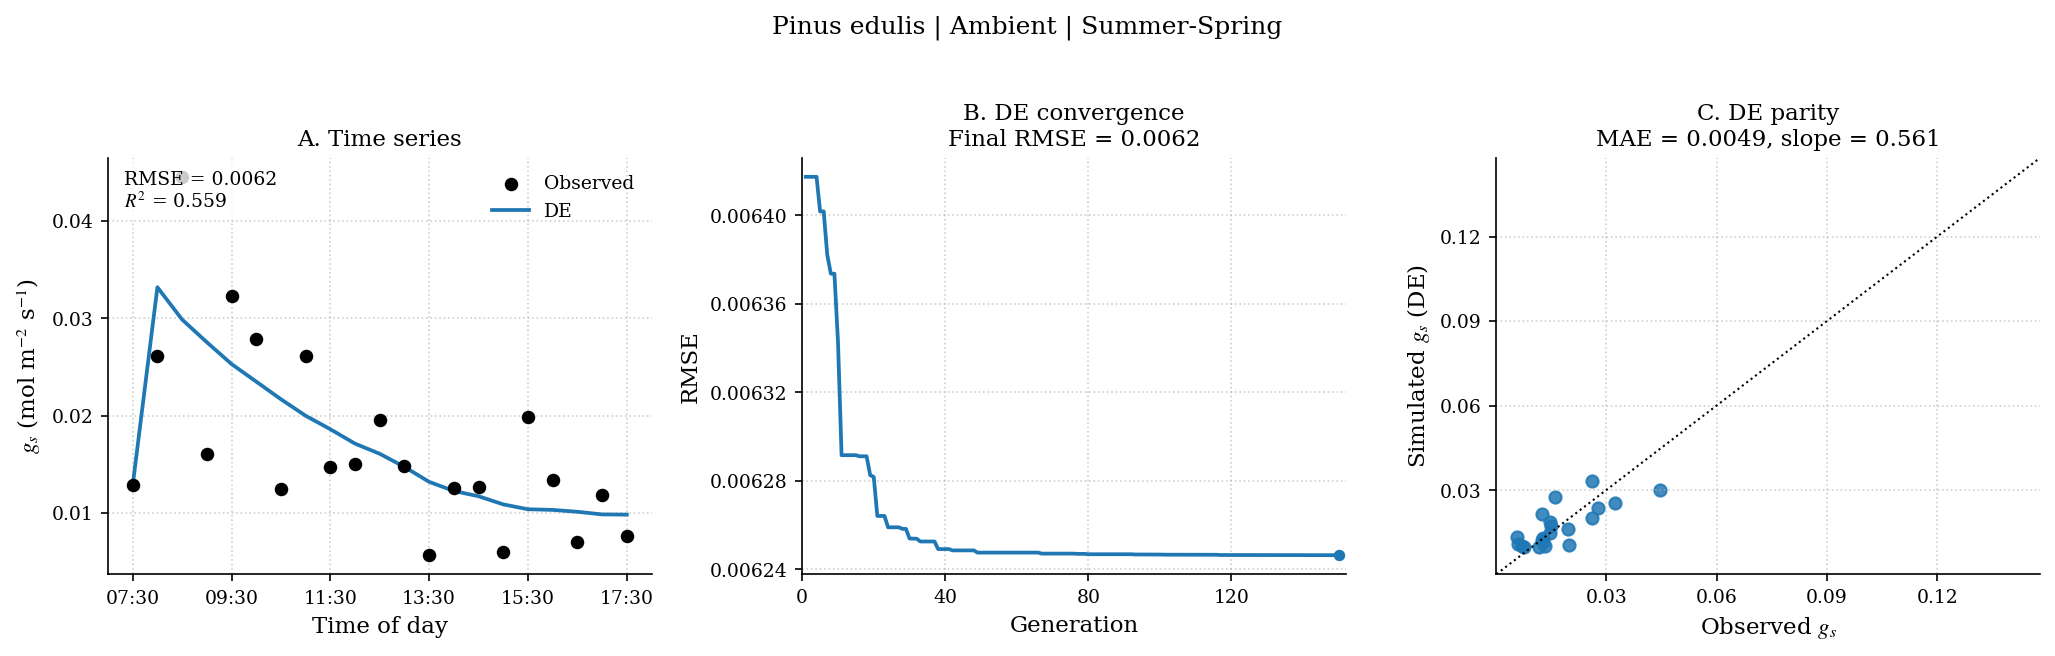

  ✓ Figure saved: Pinus edulis | Ambient | Summer-Spring


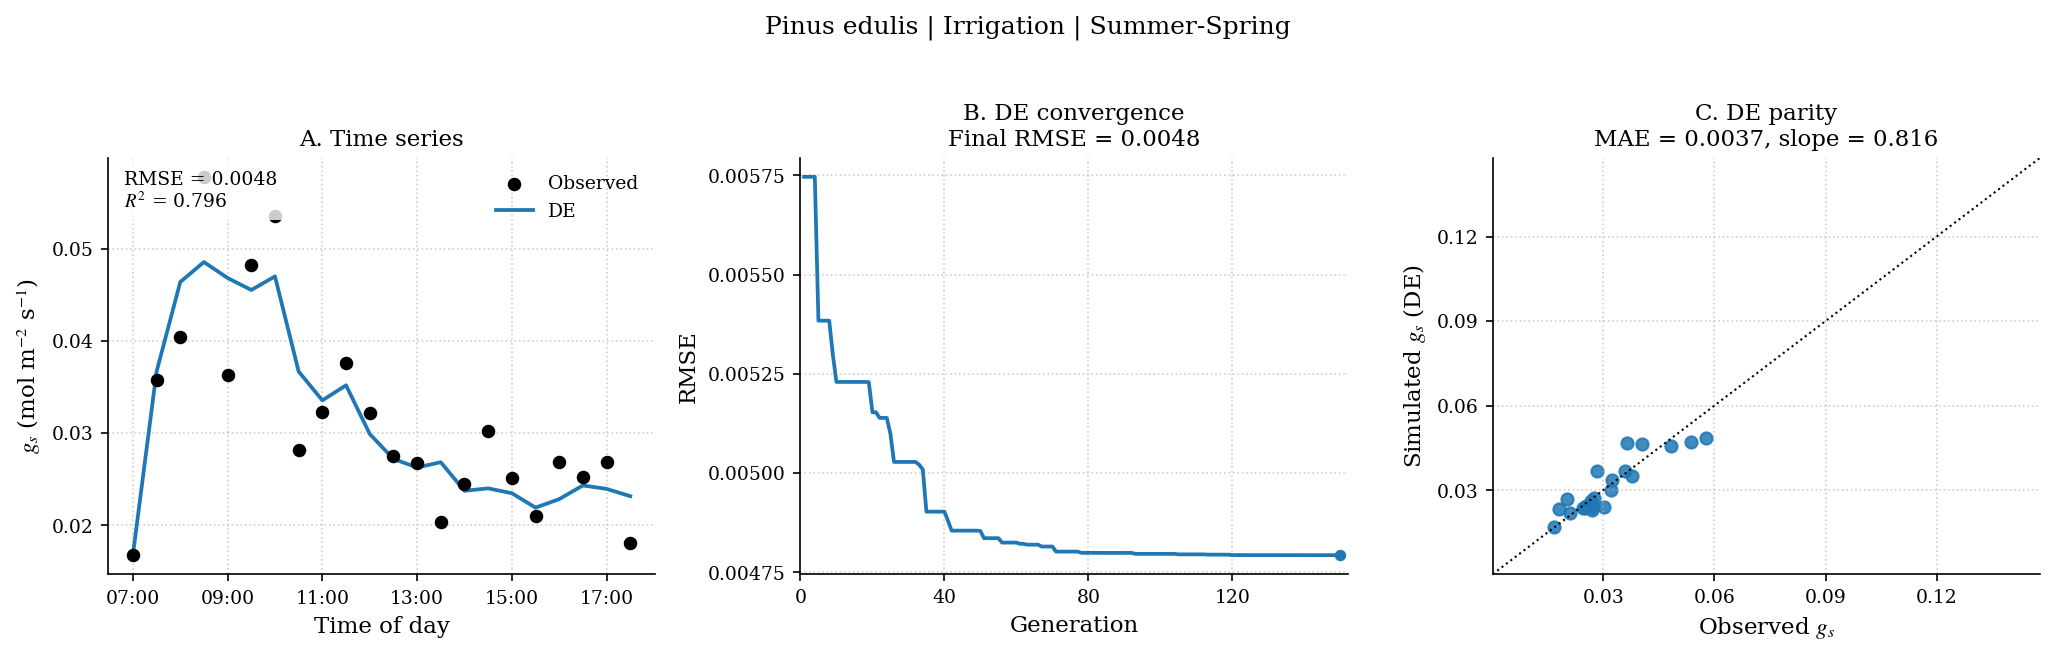

  ✓ Figure saved: Pinus edulis | Irrigation | Summer-Spring


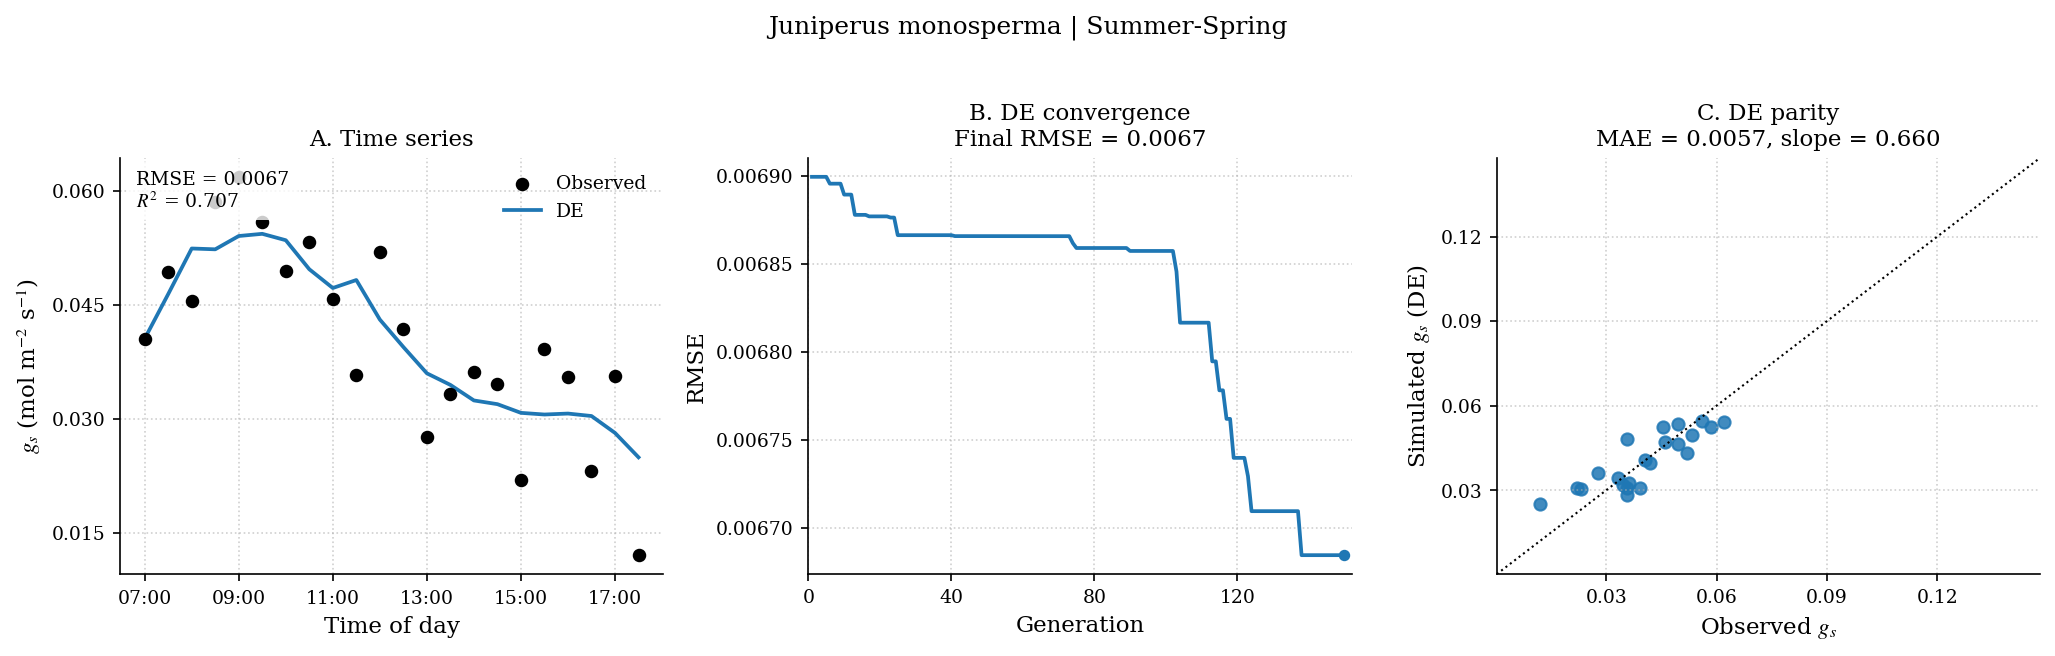

  ✓ Figure saved: Juniperus monosperma | Summer-Spring


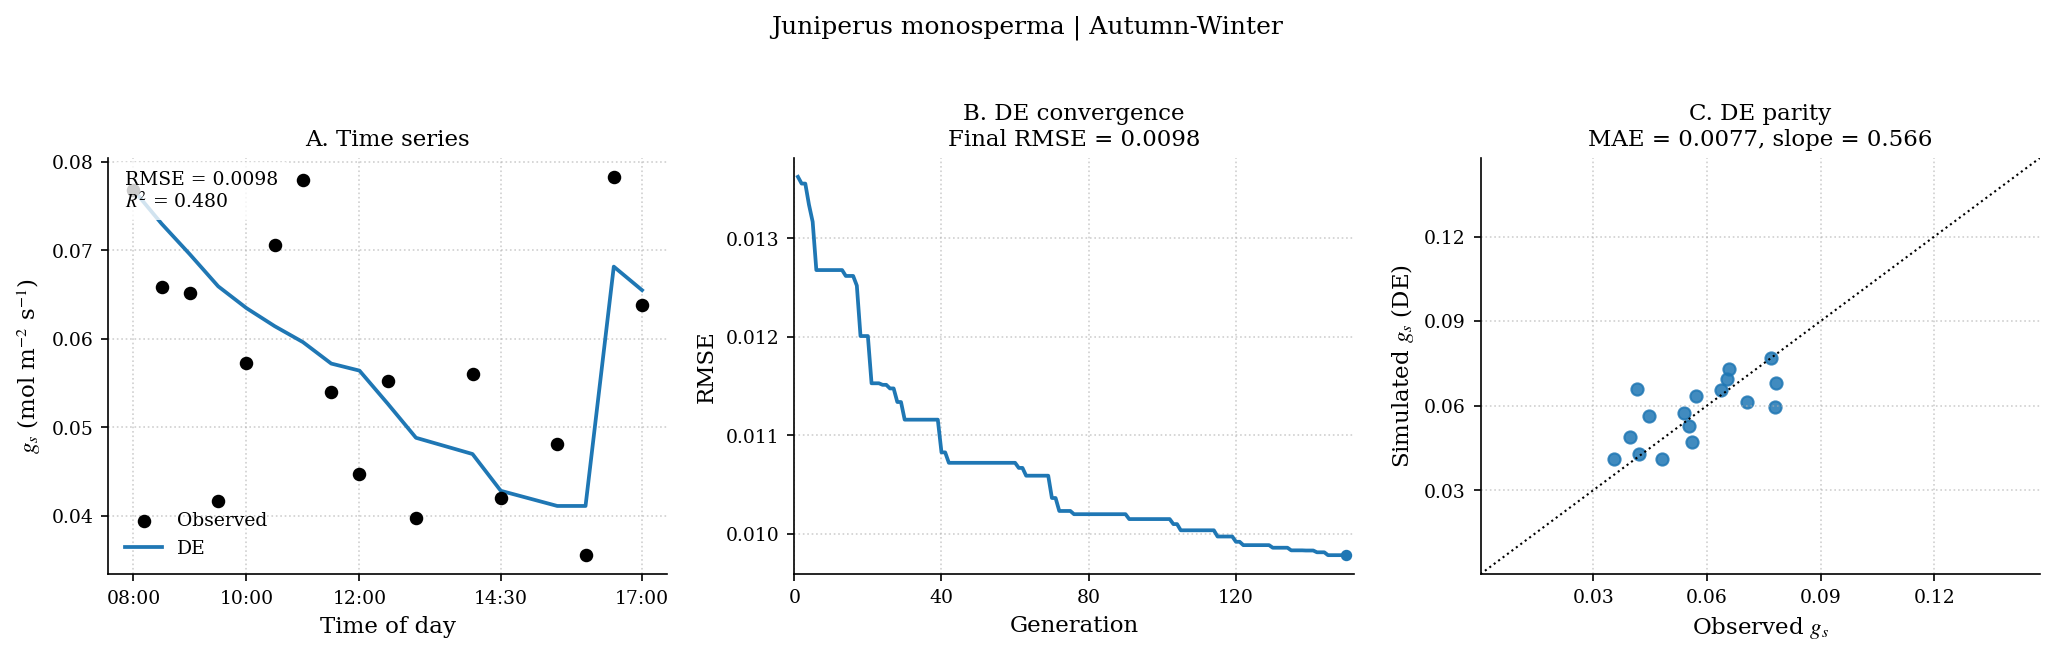

  ✓ Figure saved: Juniperus monosperma | Autumn-Winter


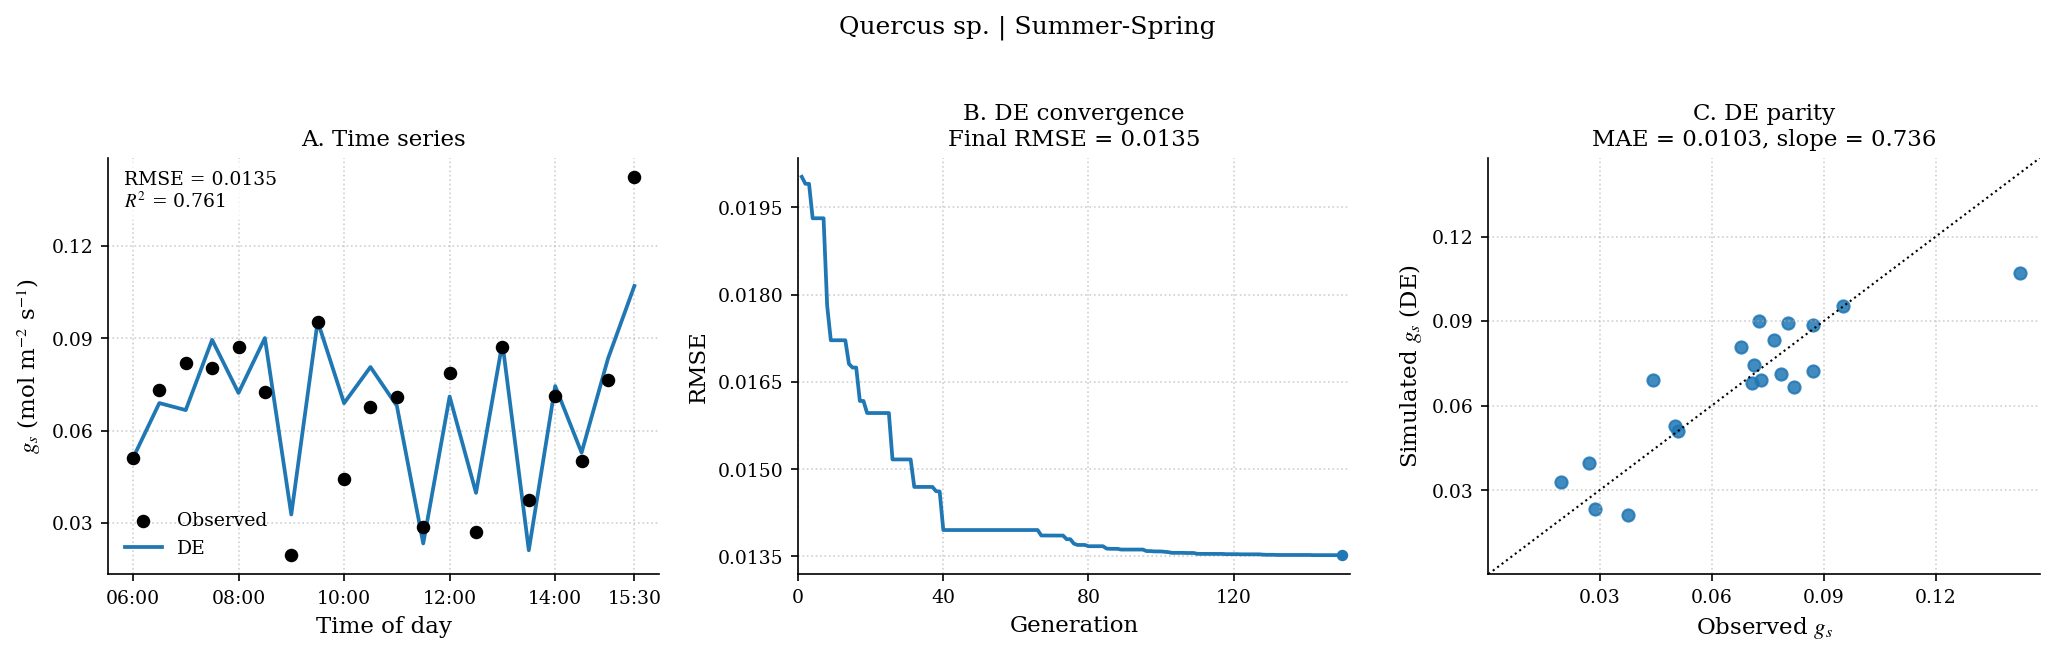

  ✓ Figure saved: Quercus sp. | Summer-Spring

PASS 2 complete.


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# PASS 2 — Compute global axis limits, then generate figures
# ══════════════════════════════════════════════════════════════════════════════
valid_idx = [i for i, d in enumerate(all_data) if d is not None]
print(f"PASS 2: Generating figures for {len(valid_idx)} valid subsets")

# Global gs range for harmonised parity-plot axes (Panel C)
gs_all = np.concatenate([
    np.concatenate([all_data[i]["gs_obs"], all_gs_de[i]]) for i in valid_idx])
gs_all       = gs_all[np.isfinite(gs_all)]
gs_global_lo = max(0.0, gs_all.min())
gs_global_hi = gs_all.max()

# Maximum number of DE generations for harmonised convergence-plot x-axis (Panel B)
max_generations = max(len(all_loss_hist[i]) for i in valid_idx) if valid_idx else 150

print(f"  Global gs  : [{gs_global_lo:.4f}, {gs_global_hi:.4f}] mol m⁻² s⁻¹")
print(f"  Max DE gen : {max_generations}")
print()

for idx in valid_idx:
    info     = all_info[idx]
    case_dir = output_dir / safe_name(info["fig_base"])
    case_dir.mkdir(exist_ok=True)

    plot_main_figure(
        title          = info["title"],
        data           = all_data[idx],
        gs_de          = all_gs_de[idx],
        metrics        = all_metrics[idx],
        loss_history   = all_loss_hist[idx],
        outpath_base   = str(case_dir / f"Fig_{safe_name(info['fig_base'])}_DE"),
        gs_global_lo   = gs_global_lo,
        gs_global_hi   = gs_global_hi,
        max_generations= max_generations,
    )
    print(f"  ✓ Figure saved: {info['title']}")

print("\nPASS 2 complete.")


---
## 12. Local Sensitivity Analysis — Figures (Figure 6)

Three bar charts are produced:
1. **Merged** — Summer-Spring cases grouped by parameter (lower panel of Figure 6)
2. **Standalone** — *Pinus edulis* Irrigation (upper-left panel)
3. **Standalone** — *Juniperus monosperma* Autumn-Winter (upper-right panel)


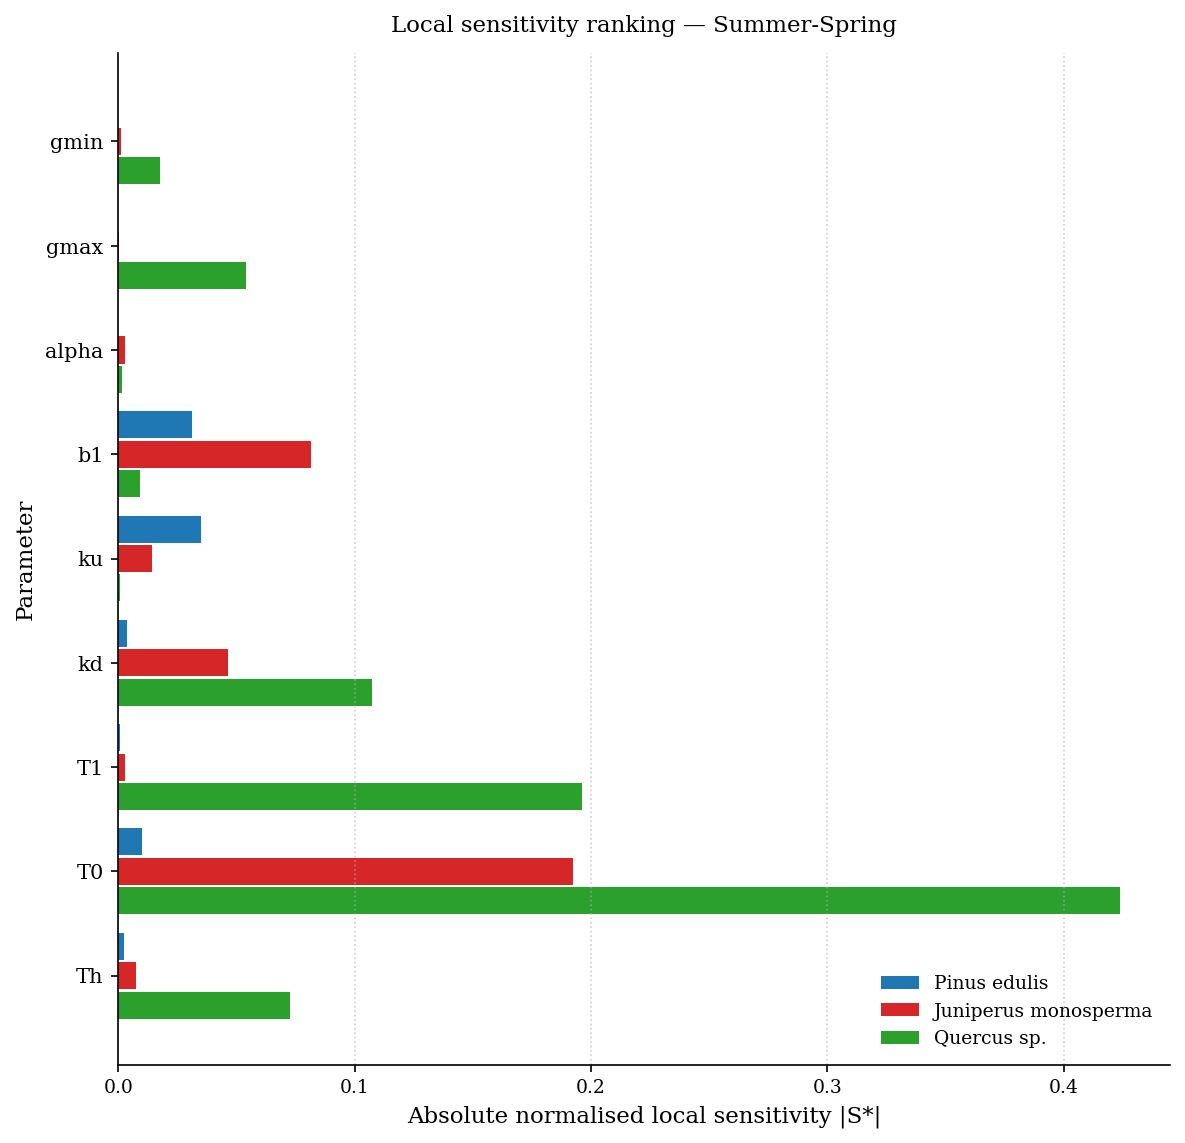

✓ Merged LSA figure (Summer-Spring) saved.


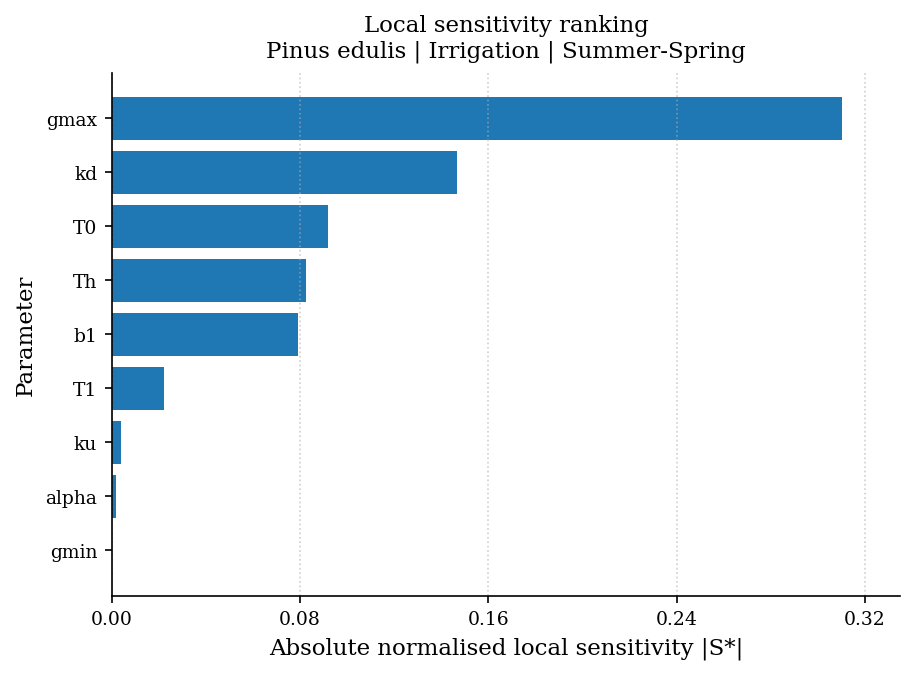

✓ LSA — Pinus edulis (Irrigation) saved.


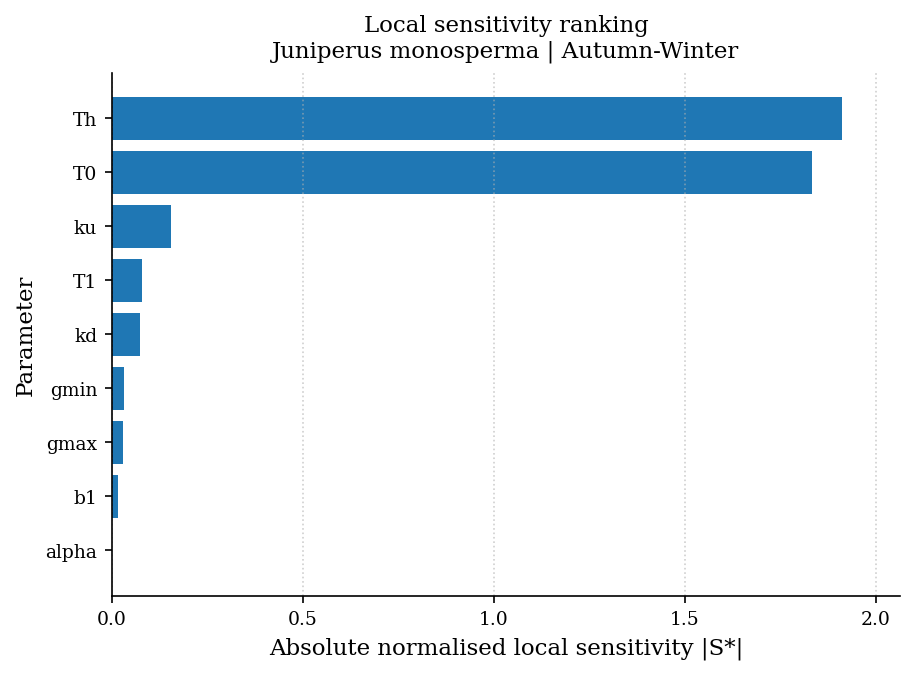

✓ LSA — Juniperus monosperma (Autumn-Winter) saved.


In [15]:
# Build a lookup: (Species, Treatment, Grupo_Estacion) → (df_summary, title)
lsa_lookup = {
    (all_info[i]["Species"], all_info[i]["Treatment"], all_info[i]["Grupo_Estacion"]):
    (all_lsa_summary[i], all_info[i]["title"])
    for i in valid_idx
}

# ── 1. Merged Summer-Spring bar chart ─────────────────────────────────────────
merged_keys = [
    ("Pinus edulis",         "Ambient",    "Verano-Primavera"),
    ("Juniperus monosperma", "All",        "Verano-Primavera"),
    ("Quercus",              "All",        "Verano-Primavera"),
]
merged_cases = [(lsa_lookup[k][0], lsa_lookup[k][1])
                for k in merged_keys if k in lsa_lookup]

if merged_cases:
    plot_lsa_merged(merged_cases,
                    str(output_dir / "Fig_LSA_merged_Summer_Spring"))
    print("✓ Merged LSA figure (Summer-Spring) saved.")

# ── 2. Pinus edulis | Irrigation (upper-left of Figure 6) ────────────────────
key = ("Pinus edulis", "Irrigation", "Verano-Primavera")
if key in lsa_lookup:
    df_s, ttl = lsa_lookup[key]
    plot_lsa_standalone(
        df_s,
        title=f"Local sensitivity ranking\n{ttl}",
        outpath_base=str(output_dir / "Fig_LSA_Pinus_Irrigation"))
    print("✓ LSA — Pinus edulis (Irrigation) saved.")

# ── 3. Juniperus monosperma | Autumn-Winter (upper-right of Figure 6) ─────────
key = ("Juniperus monosperma", "All", "Otoño-Invierno")
if key in lsa_lookup:
    df_s, ttl = lsa_lookup[key]
    plot_lsa_standalone(
        df_s,
        title=f"Local sensitivity ranking\n{ttl}",
        outpath_base=str(output_dir / "Fig_LSA_Juniperus_AutumnWinter"))
    print("✓ LSA — Juniperus monosperma (Autumn-Winter) saved.")


---
## 13. Global Sensitivity Analysis — Sobol Indices (Figure 7)

Saltelli sampling scheme followed by Sobol variance decomposition.

Two cases are analysed (Section 5.3 of the paper):
- **Best fit:** *Pinus edulis* | Irrigation | Summer-Spring
- **Lowest performance:** *Juniperus monosperma* | Autumn-Winter

**Runtime note:** Each case evaluates the dynamic model ≈ SOBOL_N × (2k+2) = 5 120 times.  
Expect 2–5 minutes per case depending on hardware.



Sobol analysis: Pinus edulis | Irrigation | Summer-Spring
  Evaluating 2816 parameter sets...
  1000/2816 evaluated...
  2000/2816 evaluated...


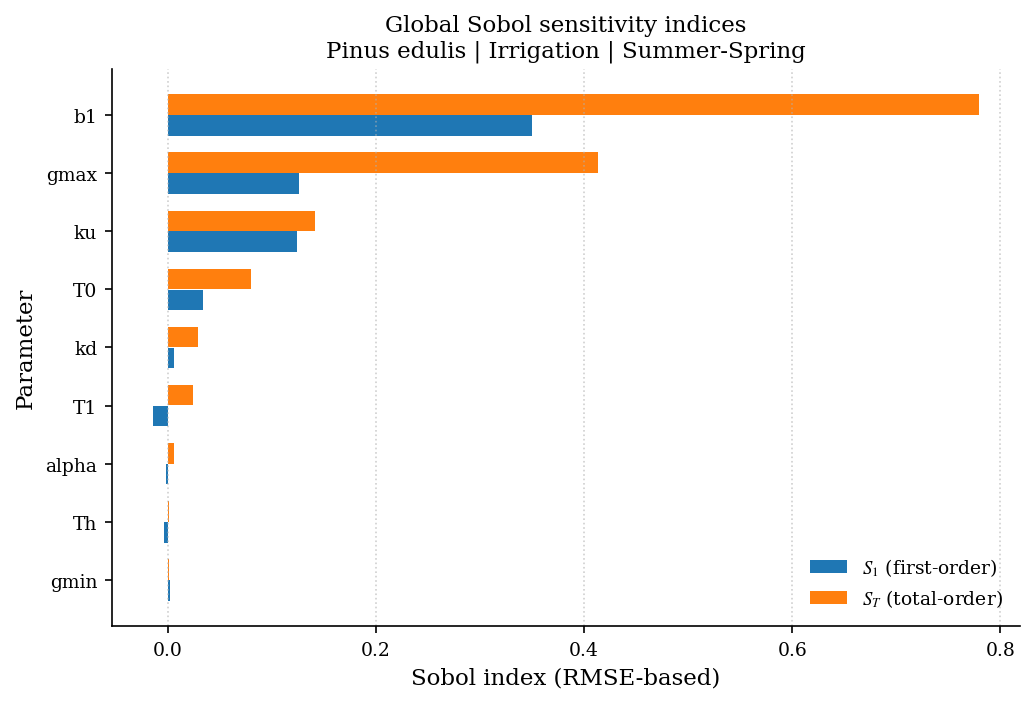

  ✓ Sobol complete (8.4s)
    Most influential (ST): b1

Sobol analysis: Juniperus monosperma | Autumn-Winter
  Evaluating 2816 parameter sets...
  1000/2816 evaluated...
  2000/2816 evaluated...


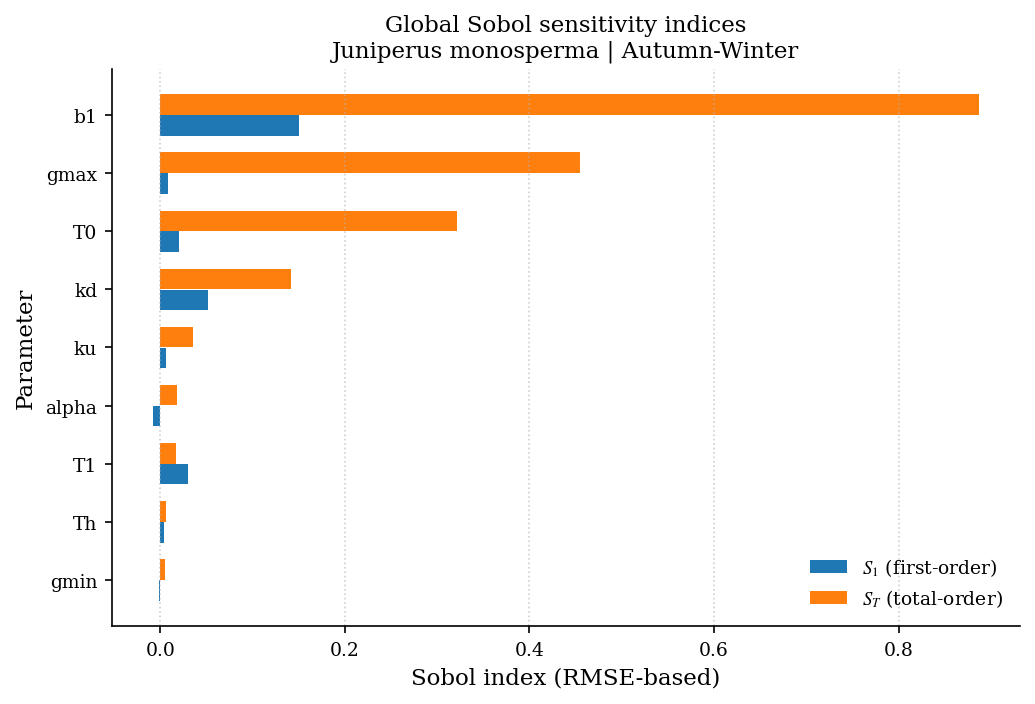

  ✓ Sobol complete (3.2s)
    Most influential (ST): b1

✓ Global Sobol analysis complete.


In [16]:
sobol_outputs = []

for idx in valid_idx:
    info = all_info[idx]
    data = all_data[idx]

    treat_key    = translate_treatment(info["Species"], info["Treatment"])
    current_case = (info["Species"], treat_key, info["Grupo_Estacion"])

    if current_case not in SOBOL_CASES:
        continue

    print(f"\nSobol analysis: {info['title']}")

    problem = {
        "num_vars": len(PARAM_NAMES),
        "names":    PARAM_NAMES,
        "bounds":   [[float(lower_DE[i]), float(upper_DE[i])]
                     for i in range(len(PARAM_NAMES))],
    }

    # Saltelli quasi-random sampling
    param_values = saltelli.sample(problem, SOBOL_N,
                                   calc_second_order=SOBOL_CALC_SECOND_ORDER)
    n_evals = len(param_values)
    print(f"  Evaluating {n_evals} parameter sets...")

    Y_rmse = np.zeros(n_evals)
    t0 = time.time()
    for i, theta in enumerate(param_values):
        Y_rmse[i] = rmse_objective(theta, data)
        if (i + 1) % 1000 == 0:
            print(f"  {i+1}/{n_evals} evaluated...")
    elapsed_sobol = time.time() - t0

    # Sobol indices
    Si = sobol.analyze(problem, Y_rmse,
                       calc_second_order=SOBOL_CALC_SECOND_ORDER,
                       print_to_console=False)

    df_sobol = pd.DataFrame({
        "Parameter":       PARAM_NAMES,
        "S1":              Si["S1"],     # first-order (direct effect)
        "S1_conf":         Si["S1_conf"],
        "ST":              Si["ST"],     # total-order (direct + interactions)
        "ST_conf":         Si["ST_conf"],
        "Interaction_gap": Si["ST"] - Si["S1"],   # magnitude of parameter interactions
        "Species":         info["Species"],
        "Treatment":       treat_key,
        "Season":          translate_season(info["Grupo_Estacion"]),
    })
    sobol_outputs.append(df_sobol)

    # ── Sobol bar chart ───────────────────────────────────────────────────────
    case_dir = output_dir / safe_name(info["fig_base"])
    case_dir.mkdir(exist_ok=True)
    dfp = df_sobol.sort_values("ST", ascending=True)
    y   = np.arange(len(dfp))

    fig, ax = plt.subplots(figsize=(7.0, 4.8))
    ax.barh(y - 0.18, dfp["S1"], height=0.35,
            label="$S_1$ (first-order)", color="#1f77b4")
    ax.barh(y + 0.18, dfp["ST"], height=0.35,
            label="$S_T$ (total-order)", color="#ff7f0e")
    ax.set_yticks(y); ax.set_yticklabels(dfp["Parameter"])
    ax.set_xlabel("Sobol index (RMSE-based)")
    ax.set_ylabel("Parameter")
    ax.set_title(f"Global Sobol sensitivity indices\n{info['title']}", fontsize=11)
    ax.legend(frameon=False)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.grid(True, axis="x", linestyle=":", alpha=0.6)
    fig.tight_layout()
    for ext in ("png", "tif"):
        fig.savefig(case_dir / f"Fig_{safe_name(info['fig_base'])}_Sobol.{ext}",
                    facecolor="white")
    plt.show(); plt.close(fig)

    print(f"  ✓ Sobol complete ({elapsed_sobol:.1f}s)")
    print(f"    Most influential (ST): {dfp.iloc[-1]['Parameter']}")

print("\n✓ Global Sobol analysis complete.")


---
## 14. Reference Model Comparison — Ball–Berry and Medlyn (Table 4, Figure 8)

For each subset, Ball–Berry and Medlyn are fitted to the same 30-min means  
using Differential Evolution. The dynamic model is also re-evaluated on the  
same aligned data grid for a direct comparison.

> This section requires `Photo_mean` and `CO2S_mean` columns in the input files.  
> Subsets lacking these columns are skipped automatically.



  Pinus edulis | Ambient | Summer-Spring
    Dynamic    — RMSE=0.0062  R²=0.559  Slope=0.561
    Ball-Berry — RMSE=0.0056  R²=0.646  Slope=0.646
    Medlyn     — RMSE=0.0031  R²=0.888  Slope=0.885


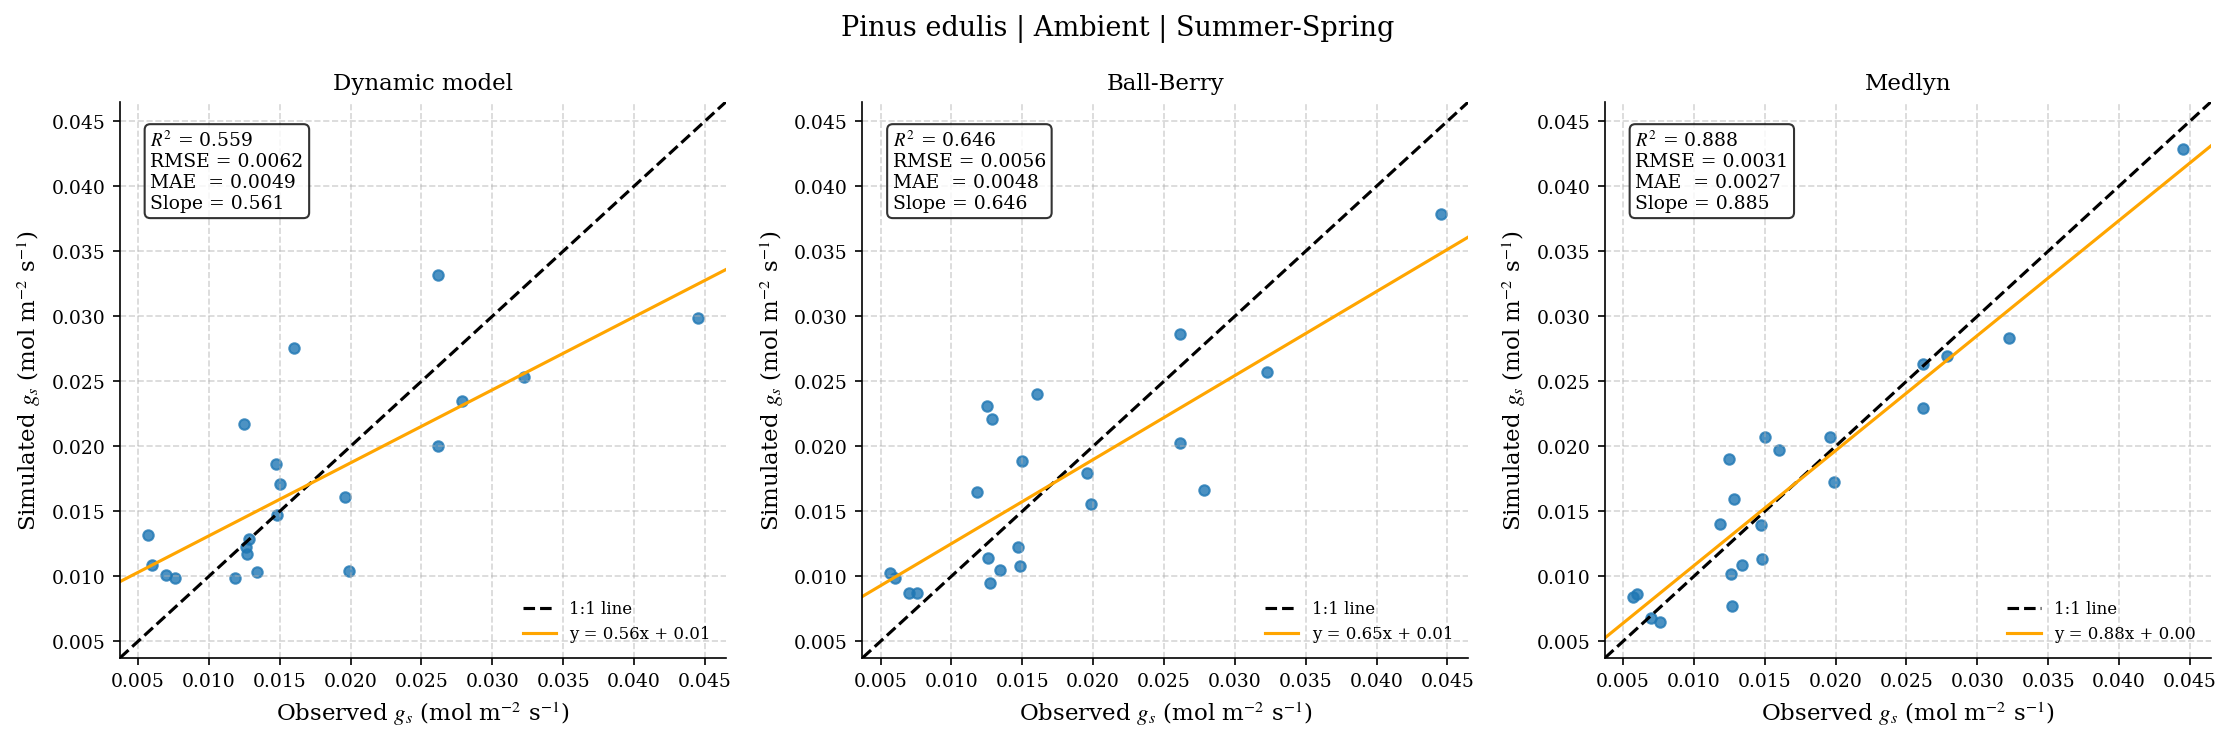


  Pinus edulis | Irrigation | Summer-Spring
    Dynamic    — RMSE=0.0048  R²=0.796  Slope=0.816
    Ball-Berry — RMSE=0.0080  R²=0.431  Slope=0.431
    Medlyn     — RMSE=0.0049  R²=0.784  Slope=0.750


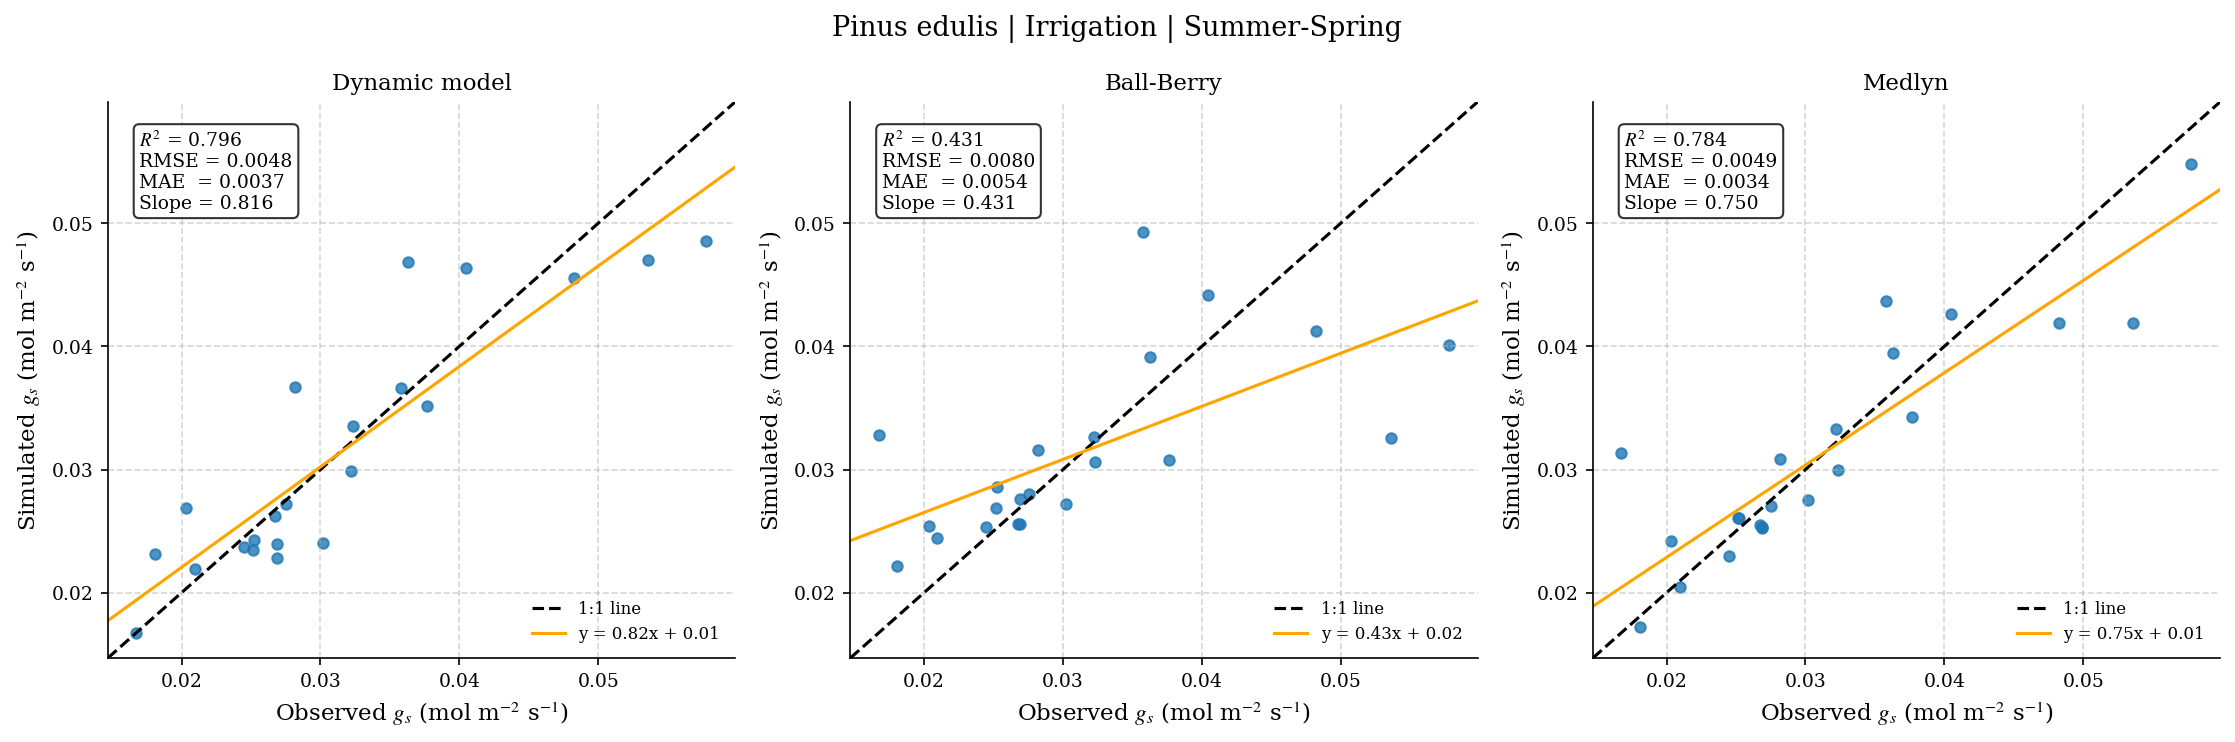


  Juniperus monosperma | Summer-Spring
    Dynamic    — RMSE=0.0067  R²=0.707  Slope=0.660
    Ball-Berry — RMSE=0.0096  R²=0.395  Slope=0.395
    Medlyn     — RMSE=0.0056  R²=0.791  Slope=0.729


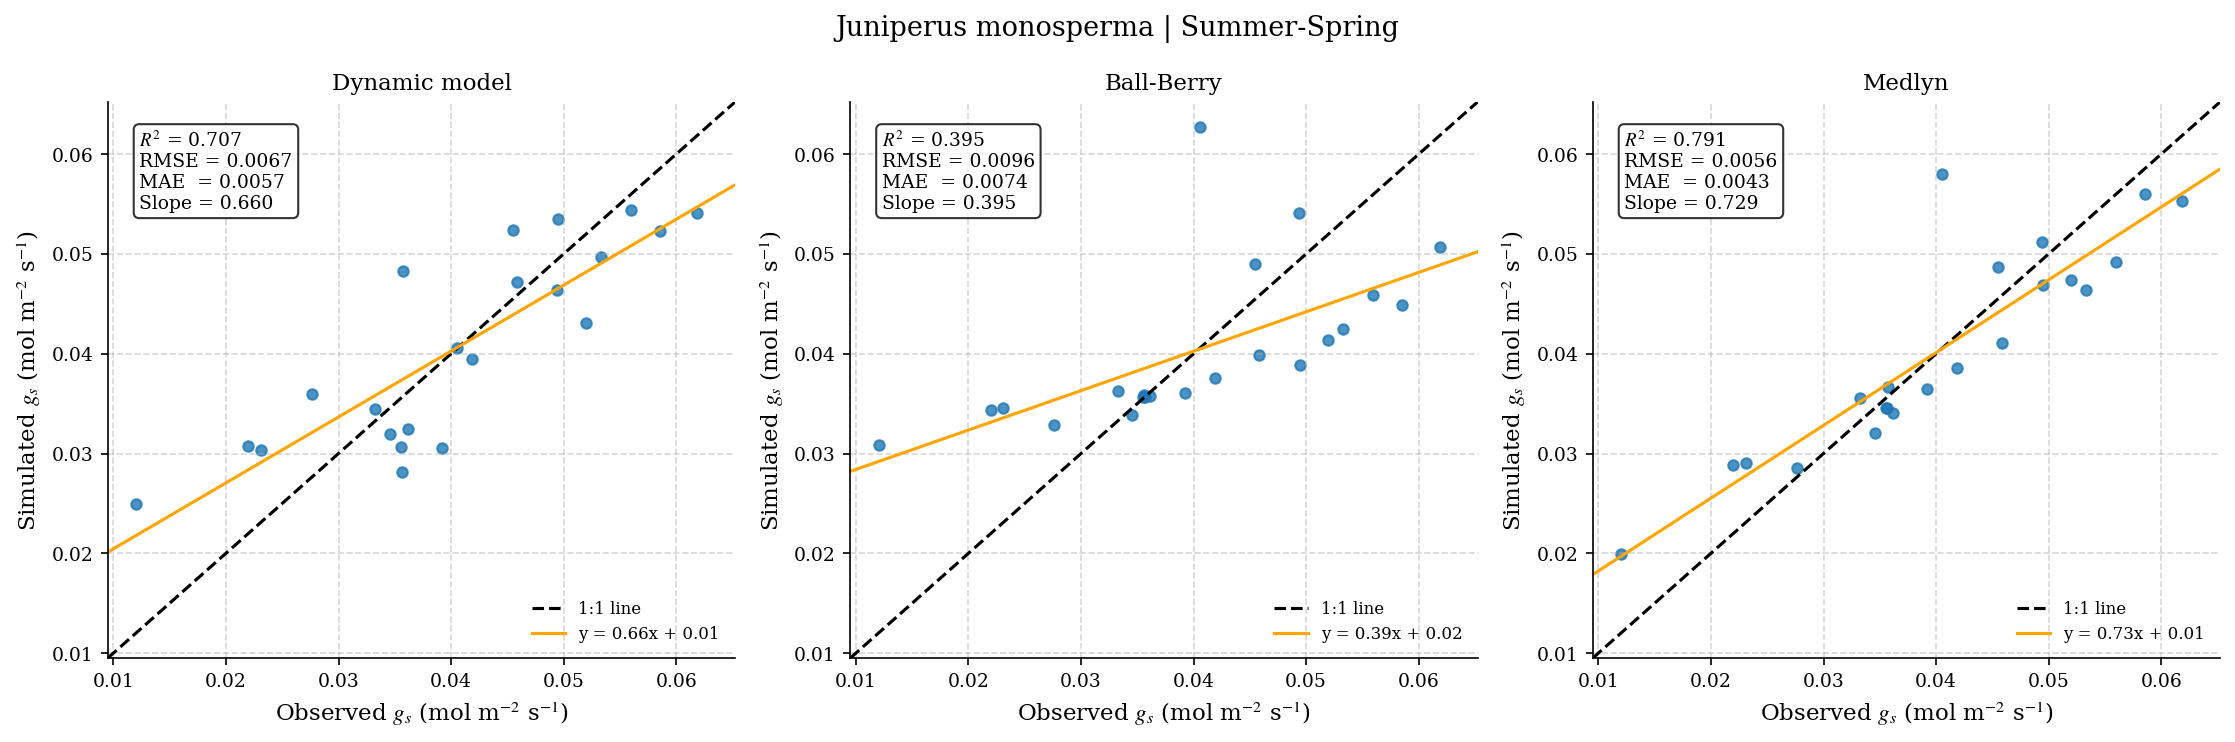


  Juniperus monosperma | Autumn-Winter
    Dynamic    — RMSE=0.0071  R²=0.739  Slope=0.719
    Ball-Berry — RMSE=0.0066  R²=0.780  Slope=0.780
    Medlyn     — RMSE=0.0045  R²=0.898  Slope=0.886


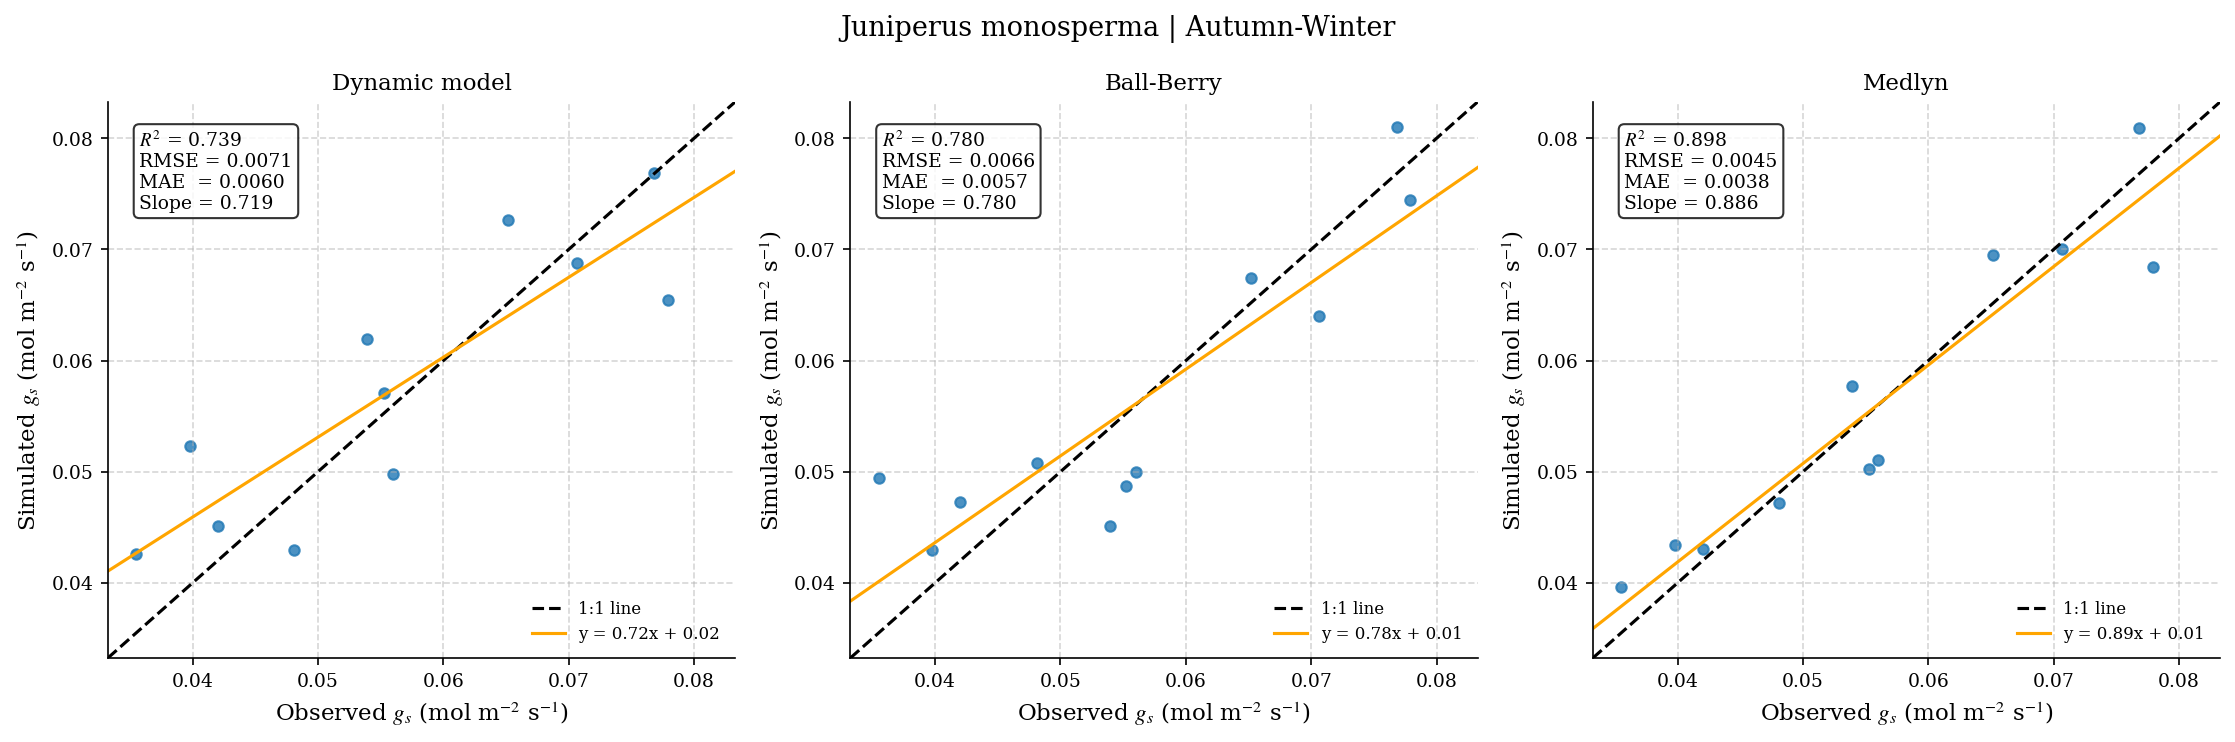


  Quercus sp. | Summer-Spring
    Dynamic    — RMSE=0.0115  R²=0.740  Slope=0.868
    Ball-Berry — RMSE=0.0084  R²=0.861  Slope=0.861
    Medlyn     — RMSE=0.0057  R²=0.935  Slope=0.922


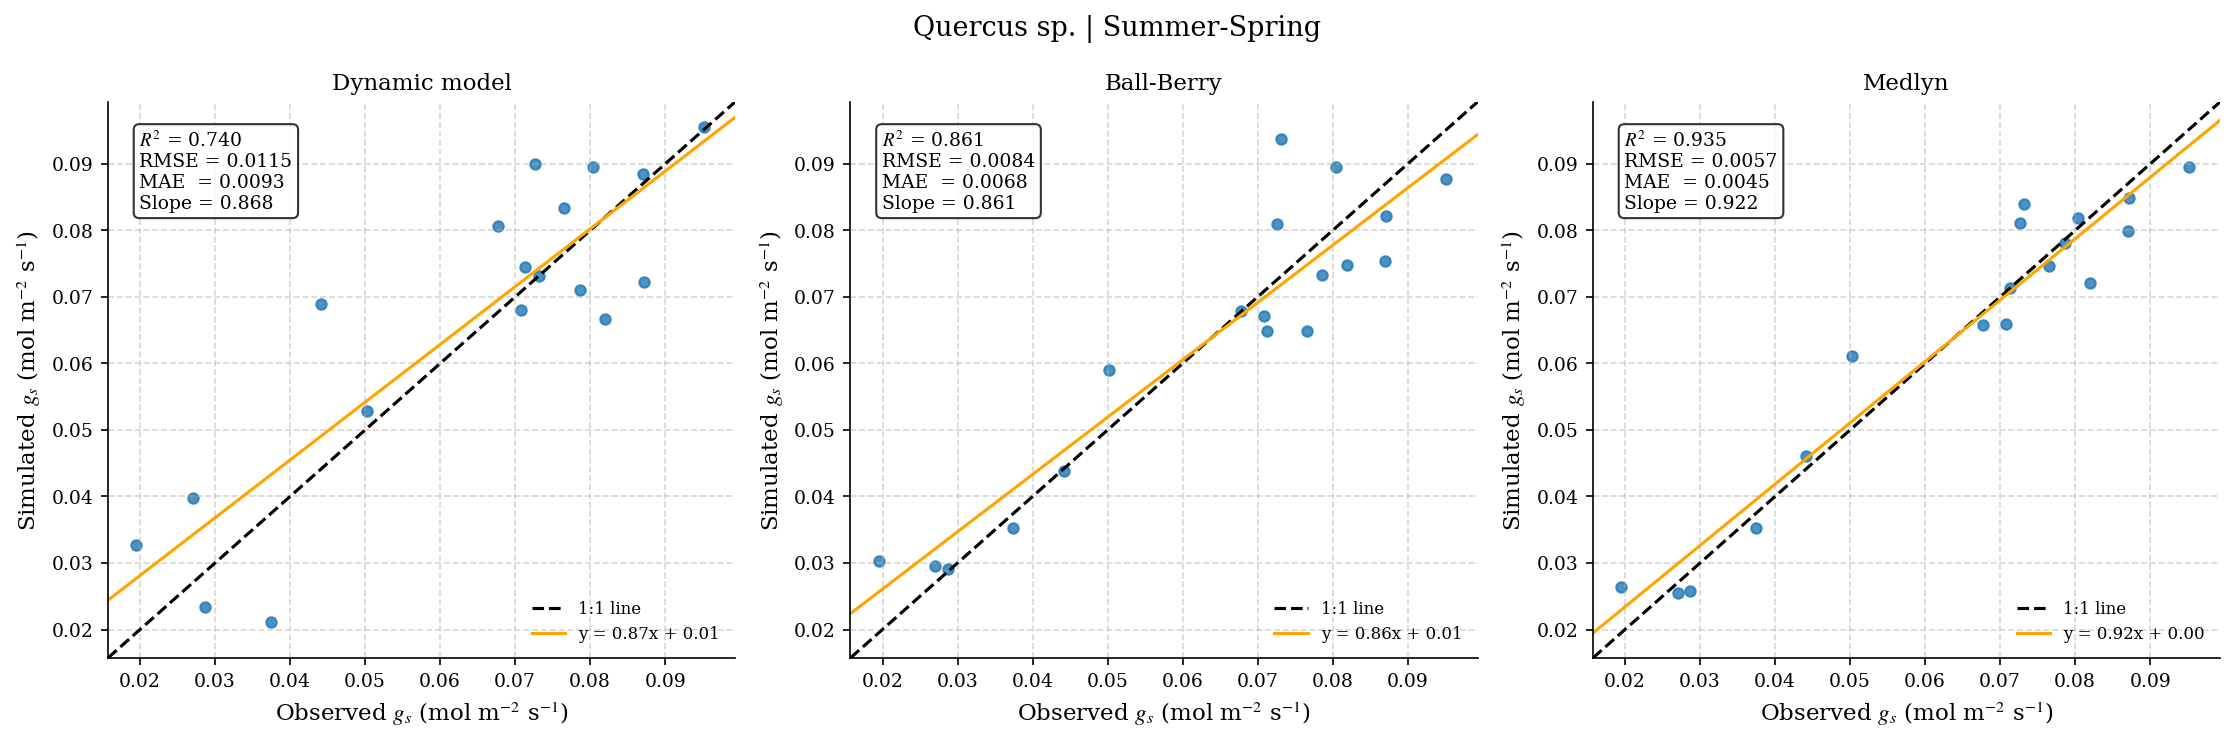


──── Table 4 — Model Comparison ────


,Species,Treatment,Season,RMSE_Dynamic,R2_Dynamic,RMSE_BallBerry,R2_BallBerry,RMSE_Medlyn,R2_Medlyn
0,Pinus edulis,Ambient,Summer-Spring,0.006246,0.559044,0.005593,0.646450,0.003144,0.888305
1,Pinus edulis,Irrigation,Summer-Spring,0.004793,0.795912,0.008003,0.431051,0.004932,0.783900
2,Juniperus monosperma,All,Summer-Spring,0.006659,0.707184,0.009573,0.394837,0.005625,0.791079
3,Juniperus monosperma,All,Autumn-Winter,0.007145,0.739295,0.006567,0.779795,0.004474,0.897767
4,Quercus,All,Summer-Spring,0.011502,0.739685,0.008390,0.861489,0.005739,0.935185



✓ Reference model comparison complete.


In [17]:
comparison_results = []

for idx in valid_idx:
    info = all_info[idx]

    # Check for physiological columns needed by Ball-Berry and Medlyn
    if "Photo_mean" not in info["data"].columns or "CO2S_mean" not in info["data"].columns:
        print(f"  Skipping {info['title']} — Photo_mean / CO2S_mean not available.")
        continue

    st = aggregate_halfhour(info["data"], info["par_col"])
    if st is None:
        continue

    # Aggregate photosynthesis and CO2 to the same 30-min grid
    extra = (info["data"][["Time_30min", "Photo_mean", "CO2S_mean"]]
             .dropna()
             .groupby("Time_30min").mean()
             .reset_index())
    merged = st.merge(extra, on="Time_30min", how="inner").dropna()
    if len(merged) < 6:
        print(f"  Skipping {info['title']} — insufficient data after merge.")
        continue

    PAR    = merged["PAR_mean"].to_numpy(float)
    Tleaf  = merged["Tl_mean"].to_numpy(float)
    Tair   = merged["Ta_mean"].to_numpy(float)
    RH     = merged["RH_mean"].to_numpy(float)
    gs_obs = merged["gs_mean"].to_numpy(float)
    A      = merged["Photo_mean"].to_numpy(float)
    Cs     = merged["CO2S_mean"].to_numpy(float)
    VPD    = calc_VPD(Tleaf, Tair, RH)
    hs     = calc_hs(Tleaf, Tair, RH)
    dt     = np.full(len(PAR) - 1, 1800.0)

    # ── Fit Ball-Berry ─────────────────────────────────────────────────────────
    res_bb  = differential_evolution(
        lambda p: np.sqrt(np.mean((gs_obs - gs_ball_berry(A, hs, Cs, *p))**2)),
        bounds=bounds_bb, seed=SEED, maxiter=120, popsize=14, tol=1e-6)
    gs_bb   = gs_ball_berry(A, hs, Cs, *res_bb.x)
    met_bb  = compute_metrics_full(gs_obs, gs_bb)

    # ── Fit Medlyn ────────────────────────────────────────────────────────────
    res_med = differential_evolution(
        lambda p: np.sqrt(np.mean((gs_obs - gs_medlyn(A, VPD, Cs, *p))**2)),
        bounds=bounds_med, seed=SEED, maxiter=120, popsize=14, tol=1e-6)
    gs_med  = gs_medlyn(A, VPD, Cs, *res_med.x)
    met_med = compute_metrics_full(gs_obs, gs_med)

    # ── Re-evaluate dynamic model on aligned grid ──────────────────────────────
    gs_de_aln = simulate_gs(all_theta[idx], PAR, Tleaf, Tair, RH, gs_obs, dt)
    met_dyn   = compute_metrics_full(gs_obs, gs_de_aln)

    print(f"\n  {info['title']}")
    print(f"    Dynamic    — RMSE={met_dyn['RMSE']:.4f}  R²={met_dyn['R2']:.3f}  Slope={met_dyn['Slope']:.3f}")
    print(f"    Ball-Berry — RMSE={met_bb['RMSE']:.4f}  R²={met_bb['R2']:.3f}  Slope={met_bb['Slope']:.3f}")
    print(f"    Medlyn     — RMSE={met_med['RMSE']:.4f}  R²={met_med['R2']:.3f}  Slope={met_med['Slope']:.3f}")

    # ── Three-model parity figure (Figure 8) ──────────────────────────────────
    case_dir = output_dir / safe_name(info["fig_base"])
    case_dir.mkdir(exist_ok=True)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    plot_obs_vs_sim_three(axes, gs_obs, gs_de_aln, gs_bb, gs_med, info["title"])
    fig.suptitle(info["title"], fontsize=13)
    plt.tight_layout()
    for ext in ("png", "tif"):
        fig.savefig(case_dir / f"Fig_{safe_name(info['fig_base'])}_comparison.{ext}",
                    facecolor="white")
    plt.show(); plt.close(fig)

    treat_en  = translate_treatment(info["Species"], info["Treatment"])
    season_en = translate_season(info["Grupo_Estacion"])
    comparison_results.append({
        "Species": info["Species"], "Treatment": treat_en, "Season": season_en,
        "RMSE_Dynamic": met_dyn["RMSE"],  "R2_Dynamic": met_dyn["R2"],
        "MAE_Dynamic":  met_dyn["MAE"],   "Slope_Dynamic": met_dyn["Slope"],
        "RMSE_BallBerry": met_bb["RMSE"], "R2_BallBerry": met_bb["R2"],
        "MAE_BallBerry":  met_bb["MAE"],  "Slope_BallBerry": met_bb["Slope"],
        "g0_BallBerry": res_bb.x[0],      "m_BallBerry": res_bb.x[1],
        "RMSE_Medlyn": met_med["RMSE"],   "R2_Medlyn": met_med["R2"],
        "MAE_Medlyn":  met_med["MAE"],    "Slope_Medlyn": met_med["Slope"],
        "g0_Medlyn": res_med.x[0],        "g1_Medlyn": res_med.x[1],
    })

df_comparison = pd.DataFrame(comparison_results)
if not df_comparison.empty:
    print("\n──── Table 4 — Model Comparison ────")
    display(df_comparison[["Species","Treatment","Season",
                            "RMSE_Dynamic","R2_Dynamic",
                            "RMSE_BallBerry","R2_BallBerry",
                            "RMSE_Medlyn","R2_Medlyn"]])

print("\n✓ Reference model comparison complete.")


---
## 15. Export Results to Excel and ZIP Archive

All results are written to a single Excel workbook with one sheet per output type.

| Sheet | Contents |
|---|---|
| `Metrics` | Table 2 — RMSE, R², MAE, slope per subset |
| `DE_Parameters` | Calibrated parameter vectors (θ) |
| `Time_Series` | Observed and simulated gs time series |
| `LSA_Curves` | RMSE vs. parameter value (OAT sweep) |
| `LSA_Summary` | Ranked sensitivity indices S* |
| `Sobol_RMSE` | First- and total-order Sobol indices |
| `Model_Comparison` | Table 4 — Dynamic vs. Ball–Berry vs. Medlyn |


In [19]:
# ── Assemble output DataFrames ────────────────────────────────────────────────
df_metrics = pd.DataFrame(results_metrics)
if not df_metrics.empty:
    df_metrics = df_metrics[["Species","Treatment","Season",
                              "RMSE","R2","MAE","Slope","Time_s_DE"]]

df_params = pd.DataFrame(results_params)
if not df_params.empty:
    df_params = df_params[["Species","Treatment","Season"] + PARAM_NAMES]

df_series          = pd.concat(results_series,       ignore_index=True) if results_series        else pd.DataFrame()
df_lsa_curve_all   = pd.concat(results_lsa_curve,   ignore_index=True) if results_lsa_curve      else pd.DataFrame()
df_lsa_summary_all = pd.concat(results_lsa_summary, ignore_index=True) if results_lsa_summary    else pd.DataFrame()
df_sobol_all       = pd.concat(sobol_outputs,        ignore_index=True) if sobol_outputs          else pd.DataFrame()
_df_comp           = df_comparison if "df_comparison" in dir() and not df_comparison.empty else pd.DataFrame()

# ── Write Excel workbook ──────────────────────────────────────────────────────
excel_path = output_dir / "stomatal_model_results.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for df_exp, sheet in [
        (df_metrics,        "Metrics"),
        (df_params,         "DE_Parameters"),
        (df_series,         "Time_Series"),
        (df_lsa_curve_all,  "LSA_Curves"),
        (df_lsa_summary_all,"LSA_Summary"),
        (df_sobol_all,      "Sobol_RMSE"),
        (_df_comp,          "Model_Comparison"),
    ]:
        if not df_exp.empty:
            df_exp.to_excel(writer, sheet_name=sheet, index=False)

print(f"✓ Excel workbook: {excel_path.resolve()}")

# ── Print summary tables ──────────────────────────────────────────────────────
print("\n──── Table 2 — Model Performance ────")
display(df_metrics.to_string(index=False) if not df_metrics.empty else "No data")

print("\n──── Calibrated Parameters ────")
display(df_params.to_string(index=False) if not df_params.empty else "No data")

print("\n──── LSA Summary (top-3 per case) ────")
if not df_lsa_summary_all.empty:
    display(df_lsa_summary_all.groupby(["Species","Treatment","Season"])
              .head(3).reset_index(drop=True).to_string(index=False))

if not df_sobol_all.empty:
    print("\n──── Sobol Indices ────")
    display(df_sobol_all.to_string(index=False))


✓ Excel workbook: /content/output_stomatal_model/stomatal_model_results.xlsx

──── Table 2 — Model Performance ────


'             Species  Treatment        Season     RMSE       R2      MAE    Slope  Time_s_DE\n        Pinus edulis    Ambient Summer-Spring 0.006246 0.559044 0.004914 0.561293  36.930665\n        Pinus edulis Irrigation Summer-Spring 0.004793 0.795912 0.003651 0.815736  38.124317\nJuniperus monosperma        All Summer-Spring 0.006659 0.707184 0.005651 0.660300  38.876745\nJuniperus monosperma        All Autumn-Winter 0.009771 0.480389 0.007666 0.566050  30.769135\n             Quercus        All Summer-Spring 0.013521 0.760522 0.010315 0.735630  35.472568'


──── Calibrated Parameters ────


'             Species  Treatment        Season     gmin     gmax    alpha       b1          ku          kd        T1        T0        Th\n        Pinus edulis    Ambient Summer-Spring 0.181115 0.158170 0.006278 3.653172  600.038512 9069.399915  5.003912 26.225062 54.979263\n        Pinus edulis Irrigation Summer-Spring 0.001286 0.484070 0.001386 3.636489 3877.986785 1801.061319  5.002882 25.060577 54.961245\nJuniperus monosperma        All Summer-Spring 0.033280 0.439636 0.000729 2.587122 4955.078808 3835.221968  9.802024 25.951166 52.153702\nJuniperus monosperma        All Autumn-Winter 0.179997 0.081962 0.000855 0.141187  605.710585 9079.598532 14.817344 29.903134 35.982412\n             Quercus        All Summer-Spring 0.155252 0.498489 0.000108 0.927410 1658.250215 1802.935486 14.993830 24.731619 41.028710'


──── LSA Summary (top-3 per case) ────


'Parameter  Base_value  Baseline_RMSE  RMSE_min  RMSE_max  Delta_RMSE_maxabs    R2_min   R2_max  MAE_min  MAE_max  S_local_norm  Abs_S_local_norm              Species  Treatment        Season\n       ku  600.038512       0.006246  0.006246  0.006482           0.000235  0.525214 0.559044 0.004897 0.004914      0.034899          0.034899         Pinus edulis    Ambient Summer-Spring\n       b1    3.653172       0.006246  0.006246  0.011494           0.005248 -0.493034 0.559043 0.004913 0.008666     -0.031094          0.031094         Pinus edulis    Ambient Summer-Spring\n       T0   26.225062       0.006246  0.006247  0.006655           0.000408  0.499531 0.558986 0.004893 0.005334      0.010060          0.010060         Pinus edulis    Ambient Summer-Spring\n     gmax    0.484070       0.004793  0.004793  0.010207           0.005414  0.074504 0.795895 0.003522 0.008492     -0.310105          0.310105         Pinus edulis Irrigation Summer-Spring\n       kd 1801.061319       0.004793  0


──── Sobol Indices ────


'Parameter        S1  S1_conf       ST  ST_conf  Interaction_gap              Species  Treatment        Season\n     gmin  0.002030 0.002977 0.001310 0.001403        -0.000721         Pinus edulis Irrigation Summer-Spring\n     gmax  0.126178 0.092930 0.413011 0.208917         0.286833         Pinus edulis Irrigation Summer-Spring\n    alpha -0.001415 0.007333 0.006495 0.005195         0.007910         Pinus edulis Irrigation Summer-Spring\n       b1  0.349978 0.185296 0.779272 0.239231         0.429294         Pinus edulis Irrigation Summer-Spring\n       ku  0.124361 0.149445 0.141191 0.071800         0.016829         Pinus edulis Irrigation Summer-Spring\n       kd  0.005581 0.020098 0.028993 0.017334         0.023412         Pinus edulis Irrigation Summer-Spring\n       T1 -0.014063 0.023505 0.024589 0.030214         0.038653         Pinus edulis Irrigation Summer-Spring\n       T0  0.033716 0.036139 0.079957 0.055917         0.046241         Pinus edulis Irrigation Summer-Spring\n

In [20]:
# ── Create a ZIP archive of all output files ─────────────────────────────────
zip_path = shutil.make_archive(str(output_dir), "zip", root_dir=str(output_dir))
print(f"✓ ZIP archive: {Path(zip_path).resolve()}")

# ── Download automatically (Google Colab only) ────────────────────────────────
if IN_COLAB:
    from google.colab import files as colab_files
    colab_files.download(str(excel_path))
    colab_files.download(zip_path)
    print("Files sent to browser for download.")
else:
    print(f"Output directory: {output_dir.resolve()}")

print("\n✓ All processing complete.")


✓ ZIP archive: /content/output_stomatal_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files sent to browser for download.

✓ All processing complete.


---
## Citation

If you use this code in your research, please cite both the paper and the repository:

**Paper:**
> Niño-Celis V, Rojas-Palma A, Espinoza Meza S, Lara-Díaz LY, Guzman-Cruz R.
> *Dynamic modeling of stomatal conductance for large-scale applications:
> integrating leaf temperature and environmental variables.*
> Environmental Modelling & Software. (2025).

**Repository:**
> Niño-Celis V et al. (2025). *stomatal-conductance-model* [Code repository].
> GitHub. https://github.com/[username]/stomatal-conductance-model

---

## References

- Ball JT, Woodrow IE, Berry JA (1987). A model predicting stomatal conductance. *Progress in Photosynthesis Research*, 4, 221–224.
- Jarvis PG (1976). The interpretation of leaf water potential and stomatal conductance. *Phil. Trans. R. Soc. Lond. B*, 273, 593–610. doi:10.1098/rstb.1976.0035
- Leuning R (1995). A critical appraisal of a combined stomatal-photosynthesis model for C3 plants. *Plant, Cell & Environment*, 18, 339–355.
- Medlyn BE et al. (2011). Reconciling the optimal and empirical approaches to modelling stomatal conductance. *Global Change Biology*, 17, 2134–2144. doi:10.1111/j.1365-2486.2010.02375.x
- Saltelli A et al. (2002). Making best use of model evaluations to compute sensitivity indices. *Computer Physics Communications*, 145, 280–297. doi:10.1016/S0010-4655(02)00280-1
- Storn R, Price K (1997). Differential evolution — a simple and efficient heuristic for global optimization. *Journal of Global Optimization*, 11, 341–359.
- Vico G et al. (2011). Effects of stomatal delays on the economics of leaf gas exchange. *New Phytologist*, 192, 640–652. doi:10.1111/j.1469-8137.2011.03847.x

---

## License

MIT License — see `LICENSE` in the repository root.

*This repository was prepared for reproducibility of results published in Environmental Modelling & Software.*
